<a href="https://colab.research.google.com/github/neeyatlotlikar/me_fy_project/blob/dev/ADF_ReRanking_MIND.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prerequisites and Dataset

In [ ]:
!pip install pandas numpy scipy gensim umap-learn hdbscan -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/ME_PROJECT/Implementation

/content/drive/MyDrive/ME_PROJECT/Implementation


In [ ]:
!mkdir -p data
%cd data

/content/drive/MyDrive/ME_PROJECT/Implementation/data


In [ ]:
model_save_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models"

I manually downloaded the dataset and uploaded the zip file to drive since it was not possible to directly download to google colab.

In [ ]:
# Unzip
!unzip MINDsmall_train.zip
!unzip MINDsmall_dev.zip

%cd ..

Archive:  MINDsmall_train.zip
   creating: MINDsmall_train/
  inflating: MINDsmall_train/behaviors.tsv  
  inflating: MINDsmall_train/news.tsv  
  inflating: MINDsmall_train/entity_embedding.vec  
  inflating: MINDsmall_train/relation_embedding.vec  
Archive:  MINDsmall_dev.zip
   creating: MINDsmall_dev/
  inflating: MINDsmall_dev/behaviors.tsv  
  inflating: MINDsmall_dev/news.tsv  
  inflating: MINDsmall_dev/entity_embedding.vec  
  inflating: MINDsmall_dev/relation_embedding.vec  
/content/drive/MyDrive/ME_PROJECT/Implementation


In [ ]:
!ls -lh data/

total 1.3G
-rw------- 1 root root  99M Feb 23 07:38 MINDlarge_dev.zip
-rw------- 1 root root 577M Feb 23 07:40 MINDlarge_test.zip
-rw------- 1 root root 506M Feb 23 07:39 MINDlarge_train.zip
drwx------ 2 root root 4.0K Aug 11  2024 MINDsmall_dev
-rw------- 1 root root  30M Feb 23 07:40 MINDsmall_dev.zip
drwx------ 2 root root 4.0K Aug 11  2024 MINDsmall_train
-rw------- 1 root root  51M Feb 23 07:40 MINDsmall_train.zip


In [ ]:
!ls -lh data/MINDsmall_dev

total 95M
-rw------- 1 root root   41M Aug 11  2024 behaviors.tsv
-rw------- 1 root root   21M Aug 11  2024 entity_embedding.vec
-rw------- 1 root root   32M Aug 11  2024 news.tsv
-rw------- 1 root root 1021K Aug 11  2024 relation_embedding.vec


In [ ]:
!ls -lh data/MINDsmall_train

total 153M
-rw------- 1 root root   88M Aug 11  2024 behaviors.tsv
-rw------- 1 root root   25M Aug 11  2024 entity_embedding.vec
-rw------- 1 root root   40M Aug 11  2024 news.tsv
-rw------- 1 root root 1021K Aug 11  2024 relation_embedding.vec


In [ ]:
!head -n 3 data/MINDsmall_train/news.tsv

N55528	lifestyle	lifestyleroyals	The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By	Shop the notebooks, jackets, and more that the royals can't live without.	https://assets.msn.com/labs/mind/AAGH0ET.html	[{"Label": "Prince Philip, Duke of Edinburgh", "Type": "P", "WikidataId": "Q80976", "Confidence": 1.0, "OccurrenceOffsets": [48], "SurfaceForms": ["Prince Philip"]}, {"Label": "Charles, Prince of Wales", "Type": "P", "WikidataId": "Q43274", "Confidence": 1.0, "OccurrenceOffsets": [28], "SurfaceForms": ["Prince Charles"]}, {"Label": "Elizabeth II", "Type": "P", "WikidataId": "Q9682", "Confidence": 0.97, "OccurrenceOffsets": [11], "SurfaceForms": ["Queen Elizabeth"]}]	[]
N19639	health	weightloss	50 Worst Habits For Belly Fat	These seemingly harmless habits are holding you back and keeping you from shedding that unwanted belly fat for good.	https://assets.msn.com/labs/mind/AAB19MK.html	[{"Label": "Adipose tissue", "Type": "C", "WikidataId": "Q193583", "Confidence": 1.0

In [ ]:
!head -n 3 data/MINDsmall_train/behaviors.tsv

1	U13740	11/11/2019 9:05:58 AM	N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801	N55689-1 N35729-0
2	U91836	11/12/2019 6:11:30 PM	N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6233 N14340 N48031 N62285 N44383 N23061 N16290 N6244 N45099 N58715 N59049 N7023 N50528 N42704 N46082 N8275 N15710 N59026 N8429 N30867 N56514 N19709 N31402 N31741 N54889 N9798 N62612 N2663 N16617 N6087 N13231 N63317 N61388 N59359 N51163 N30698 N34567 N54225 N32852 N55833 N64467 N3142 N13912 N29802 N44462 N29948 N4486 N5398 N14761 N47020 N65112 N31699 N37159 N61101 N14761 N3433 N10438 N61355 N21164 N22976 N2511 N48390 N58224 N48742 N35458 N24611 N37509 N21773 N41011 N19041 N25785	N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N33677-0 N7821-0 N6890-0
3	U73700	11/14/2019 7:01:48 AM	N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N24233 N62058 N26378 N49475 N18870	N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-

In [ ]:
!file data/MINDsmall_train/entity_embedding.vec

data/MINDsmall_train/entity_embedding.vec: ASCII text, with very long lines (970)


In [ ]:
!head -n 5 data/MINDsmall_train/entity_embedding.vec

Q41	-0.063388	-0.181451	0.057501	-0.091254	-0.076217	-0.052525	0.050500	-0.224871	-0.018145	0.030722	0.064276	0.073063	0.039489	0.159404	-0.128784	0.016325	0.026797	0.137090	0.001849	-0.059103	0.012091	0.045418	0.000591	0.211337	-0.034093	-0.074582	0.014004	-0.099355	0.170144	0.109376	-0.014797	0.071172	0.080375	0.045563	-0.046462	0.070108	0.015413	-0.020874	-0.170324	-0.001130	0.059810	0.054342	0.027358	-0.028995	-0.224508	0.066281	-0.200006	0.018186	0.082396	0.167178	-0.136239	0.055134	-0.080195	-0.001460	0.031078	-0.017084	-0.091176	-0.036916	0.124642	-0.098185	-0.054836	0.152483	-0.053712	0.092816	-0.112044	-0.072247	-0.114896	-0.036541	-0.186339	-0.160610	0.037342	-0.133474	0.110080	0.070678	-0.005586	-0.046667	-0.072010	0.086424	0.026165	0.030561	0.077888	-0.117226	0.211597	0.112512	0.079999	-0.083398	-0.121117	0.071751	-0.017654	-0.134979	-0.051949	0.001861	0.124535	-0.151043	-0.263698	-0.103607	0.020007	-0.101157	-0.091567	0.035234	
Q1860	0.060958	0.069934	0.015832	0.079471	-0.

In [ ]:
df = pd.read_csv('data/MINDsmall_train/behaviors.tsv', sep='\t', index_col=0, nrows=25, header=None)
df.head()

,1,2,3,4
0,,,,
1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [ ]:
import pandas as pd

# Peek at files
for split in ['data/MINDsmall_dev', 'data/MINDsmall_train']:
  print(f"{split} News file shape:", pd.read_csv(f'{split}/news.tsv', sep='\t', nrows=3).shape)
  print("Interactions files:")
  df = pd.read_csv(f'{split}/behaviors.tsv', sep='\t', nrows=1000, header=None)
  print(f"  behaviors.tsv: {len(df)} rows, {df[1].nunique()} users, {df[2].nunique()} click history, {df[3].nunique()} impressions")
  for f in ['entity_embedding.vec', 'relation_embedding.vec']:
    df = pd.read_csv(f'{split}/{f}', sep='\t', nrows=1000, header=None)
    print(f"  {f}: {df.shape} shape, {df.iloc[:5, 0].tolist()} sample ids, {df.shape[1] - 1} vector dimensions")
  print()


data/MINDsmall_dev News file shape: (3, 8)
Interactions files:
  behaviors.tsv: 1000 rows, 996 users, 994 click history, 961 impressions
  entity_embedding.vec: (1000, 102) shape, ['Q34433', 'Q41', 'Q56037', 'Q1860', 'Q39631'] sample ids, 101 vector dimensions
  relation_embedding.vec: (1000, 102) shape, ['P31', 'P21', 'P106', 'P735', 'P108'] sample ids, 101 vector dimensions

data/MINDsmall_train News file shape: (3, 8)
Interactions files:
  behaviors.tsv: 1000 rows, 988 users, 1000 click history, 974 impressions
  entity_embedding.vec: (1000, 102) shape, ['Q41', 'Q1860', 'Q39631', 'Q30', 'Q60'] sample ids, 101 vector dimensions
  relation_embedding.vec: (1000, 102) shape, ['P31', 'P21', 'P106', 'P735', 'P108'] sample ids, 101 vector dimensions



# Load & Explore MIND Data Structure

In [ ]:
import pandas as pd
import numpy as np

print("Loading MIND Data...")
behv_cols = ['impr_id', 'user_id', 'time', 'hist', 'imprs']
train_beh = pd.read_csv('data/MINDsmall_train/behaviors.tsv', sep='\t', names=behv_cols, nrows=10000)
dev_beh = pd.read_csv('data/MINDsmall_dev/behaviors.tsv', sep='\t', names=behv_cols, nrows=10000)

news_cols = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']
train_news = pd.read_csv('data/MINDsmall_train/news.tsv', sep='\t', names=news_cols, nrows=10000)
dev_news = pd.read_csv('data/MINDsmall_dev/news.tsv', sep='\t', names=news_cols, nrows=10000)

print(f"  Train: {len(train_beh)} impressions, {train_beh['user_id'].nunique()} users")
print(f"  Dev:   {len(dev_beh)} impressions, {dev_beh['user_id'].nunique()} users")
print(f"  Train news: {len(train_news)} articles")
print(f"  Dev news: {len(dev_news)} articles")

print("\nBehaviors sample:")
print(train_beh.head(2))
print("\nNews sample:")
print(train_news.head(2))


Loading MIND Data...
  Train: 10000 impressions, 8683 users
  Dev:   10000 impressions, 9382 users
  Train news: 10000 articles
  Dev news: 10000 articles

Behaviors sample:
   impr_id user_id                   time  \
0        1  U13740  11/11/2019 9:05:58 AM   
1        2  U91836  11/12/2019 6:11:30 PM   

                                                hist  \
0  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
1  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   

                                               imprs  
0                                  N55689-1 N35729-0  
1  N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...  

News sample:
  news_id   category      subcategory  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   

                                               title  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   

                                            abstr

In [ ]:
# Sample dev user
dev_sample_user = list(dev_user_news.keys())[80]
dev_true_items = dev_user_news[dev_sample_user]
dev_user_idx = user_to_idx.get(dev_sample_user, 0)
print(f"\nSample dev user {dev_sample_user} clicked {len(dev_true_items)} items")
print("True clicks:", dev_true_items[:5])


Sample dev user U65757 clicked 2 items
True clicks: ['N28307', 'N21484']


In [ ]:
def parse_impressions(impr_str):
    """Parse MIND 'N123-1 N456-0' → list of (news_id, clicked)"""
    items = impr_str.split()
    news_ids = [item.split('-')[0] for item in items]
    clicks = [int(item.split('-')[1]) for item in items]
    return list(zip(news_ids, clicks))

# Test parsing
sample_impr = train_beh['imprs'].iloc[0]
parsed = parse_impressions(sample_impr)

print("Sample impression:", sample_impr[:50]+"...")
print("Parsed clicks:", parsed[:5])
print(f"\nFound {sum(c[1] for c in parsed)} clicks in this impression")

# Count clicks across sample
train_sample = train_beh.head(100)
total_clicks = 0
for impr in train_sample['imprs']:
    clicks = parse_impressions(impr)
    total_clicks += sum(c[1] for c in clicks)

print(f"\nSample stats: {total_clicks} total clicks in 100 impressions")


Sample impression: N55689-1 N35729-0...
Parsed clicks: [('N55689', 1), ('N35729', 0)]

Found 1 clicks in this impression

Sample stats: 137 total clicks in 100 impressions


### Data Categories and Sub-Categories Visualization

In [ ]:
!pip install wordcloud -q

In [ ]:
combined_news = pd.concat([train_news, dev_news], ignore_index=True)
print(f"Combined news dataframe shape: {combined_news.shape}")

categories = combined_news['category']
subcategories = combined_news['subcategory']

print("Categories head:", categories.head())
print("Subcategories head:", subcategories.head())

Combined news dataframe shape: (20000, 8)
Categories head: 0    lifestyle
1       health
2         news
3       health
4       health
Name: category, dtype: object
Subcategories head: 0    lifestyleroyals
1         weightloss
2          newsworld
3             voices
4            medical
Name: subcategory, dtype: object


In [ ]:
print("Category Value Counts:\n", categories.value_counts().head(10))
print("\nSubcategory Value Counts:\n", subcategories.value_counts().head(10))

Category Value Counts:
 category
news            5070
sports          4832
lifestyle       1614
finance         1356
foodanddrink    1300
health          1210
autos            933
travel           880
video            722
weather          599
Name: count, dtype: int64

Subcategory Value Counts:
 subcategory
football_nfl                2042
newsus                      1907
newspolitics                 936
newscrime                    726
newsworld                    619
weathertopstories            599
baseball_mlb                 569
football_ncaa                518
basketball_nba               452
newsscienceandtechnology     387
Name: count, dtype: int64


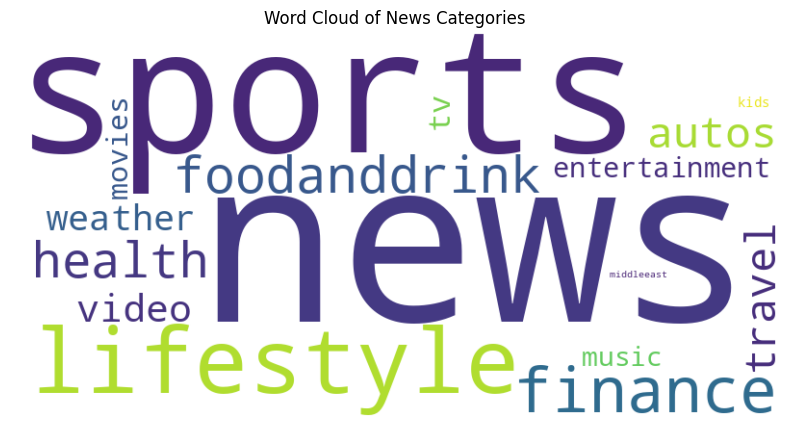

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud for categories
category_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(categories.value_counts())

plt.figure(figsize=(10, 5))
plt.imshow(category_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of News Categories')
plt.show()


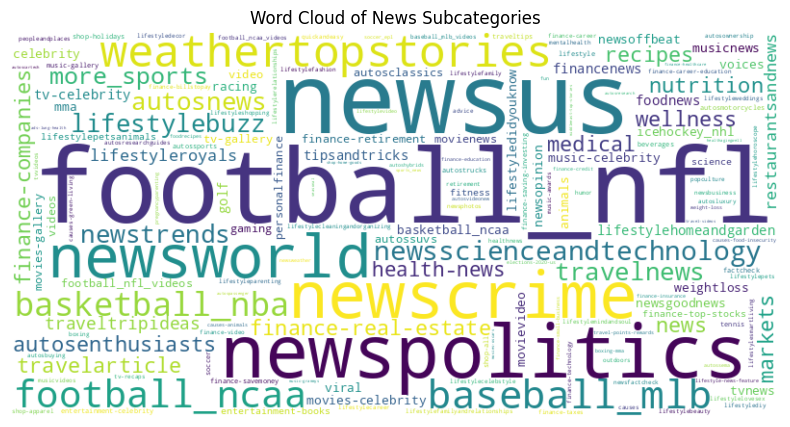

In [ ]:
subcategory_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(subcategories.value_counts())

plt.figure(figsize=(10, 5))
plt.imshow(subcategory_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of News Subcategories')
plt.show()

# Using lightfm

## Model Building

In [ ]:
!pip install lightfm-next -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:00


In [ ]:
from lightfm import LightFM
from lightfm.data import Dataset

print("LightFM installed successfully!")

LightFM installed successfully!


In [ ]:
import pandas as pd

behaviors_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_train/behaviors.tsv"

# Column names from MIND documentation
columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

# Load dataset
behaviors = pd.read_csv(
    behaviors_path,
    sep="\t",
    names=columns
)

# Show dataset shape
print("Dataset shape:", behaviors.shape)

# Show first rows
behaviors.head()

Dataset shape: (156965, 5)


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [ ]:
clicked_data = []

for _, row in behaviors.iterrows():

    user = row["user_id"]
    impressions = row["impressions"].split()

    for imp in impressions:
        news_id, label = imp.split("-")

        if label == "1":
            clicked_data.append((user, news_id))

# Convert to dataframe
clicks_df = pd.DataFrame(clicked_data, columns=["user_id", "news_id"])

print("Total click interactions:", len(clicks_df))
clicks_df.head()

Total click interactions: 236344


,user_id,news_id
0,U13740,N55689
1,U91836,N17059
2,U73700,N23814
3,U34670,N49685
4,U8125,N8400


In [ ]:
from lightfm.data import Dataset

# Create LightFM dataset object
dataset = Dataset()

# Fit dataset with users and items
dataset.fit(
    users=clicks_df["user_id"].unique(),
    items=clicks_df["news_id"].unique()
)

# Build interaction matrix
(interactions, weights) = dataset.build_interactions(
    [(row.user_id, row.news_id) for row in clicks_df.itertuples()]
)

print("Interaction matrix shape:", interactions.shape)
print("Total interactions:", interactions.nnz)

Interaction matrix shape: (50000, 7713)
Total interactions: 236344


In [ ]:
from lightfm import LightFM
import joblib

# Create the model
model = LightFM(
    loss="warp",        # good for implicit feedback ranking
    no_components=32,   # embedding size
    learning_rate=0.05
)

# Train the model
model.fit(
    interactions,
    epochs=10,
    num_threads=4,
    verbose=True
)

joblib.dump(model, f'{model_save_path}/lightfm_mind.joblib')

print("\nCF model trained successfully!")

Epoch: 100%|██████████| 10/10 [00:05<00:00,  1.75it/s]


CF model trained successfully!


In [ ]:
# Load saved model
import joblib

model_save_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/models"
model = joblib.load(f'{model_save_path}/lightfm_mind.joblib')


In [ ]:
import numpy as np

# Get mapping from dataset
user_id_map, user_feature_map, item_id_map, item_feature_map = dataset.mapping()

# Reverse mapping (index → original ID)
inv_item_map = {v: k for k, v in item_id_map.items()}

# Choose a sample user
user_index = 0

# Predict scores for all items
scores = model.predict(user_index, np.arange(interactions.shape[1]))

# Get top 10 items
top_items = np.argsort(-scores)[:10]

print("Top 10 recommended news articles:")
for item in top_items:
    print(inv_item_map[item])

Top 10 recommended news articles:
N55689
N63970
N35729
N47061
N7821
N49279
N62360
N41020
N53585
N40839


## ADF Preparation

In [ ]:
# Path to news metadata
news_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_train/news.tsv"

news_columns = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

news_df = pd.read_csv(
    news_path,
    sep="\t",
    names=news_columns
)

print("News dataset shape:", news_df.shape)

news_df.head()

News dataset shape: (51282, 8)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [ ]:
# Fill missing values to avoid errors
news_df["title"] = news_df["title"].fillna("")
news_df["abstract"] = news_df["abstract"].fillna("")

# Combine title and abstract
news_df["text"] = news_df["title"] + " " + news_df["abstract"]

# Keep only columns we need for now
news_text_df = news_df[["news_id", "text"]]

print("Prepared text dataset shape:", news_text_df.shape)

news_text_df.head()

Prepared text dataset shape: (51282, 2)


,news_id,text
0,N55528,"The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,50 Worst Habits For Belly Fat These seemingly ...
2,N61837,The Cost of Trump's Aid Freeze in the Trenches...
3,N53526,I Was An NBA Wife. Here's How It Affected My M...
4,N38324,"How to Get Rid of Skin Tags, According to a De..."


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_features=5000,     # limit vocabulary size
    stop_words="english",  # remove common words
    min_df=5               # ignore very rare words
)

doc_term_matrix = vectorizer.fit_transform(news_text_df["text"])

print("Document-Term Matrix shape:", doc_term_matrix.shape)

Document-Term Matrix shape: (51282, 5000)


## LDA decomposition

Discover hidden topics in articles. Generates a topic distribution vector.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# number of topics
n_topics = 20

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    verbose=1
)

lda_matrix = lda_model.fit_transform(doc_term_matrix)

print("LDA topic matrix shape:", lda_matrix.shape)

iteration: 1 of max_iter: 10
iteration: 2 of max_iter: 10
iteration: 3 of max_iter: 10
iteration: 4 of max_iter: 10
iteration: 5 of max_iter: 10
iteration: 6 of max_iter: 10
iteration: 7 of max_iter: 10
iteration: 8 of max_iter: 10
iteration: 9 of max_iter: 10
iteration: 10 of max_iter: 10
LDA topic matrix shape: (51282, 20)


In [ ]:
import joblib
joblib.dump(lda_matrix, f'{model_save_path}/lda_matrix.joblib')

In [ ]:
# Load saved lda matrix
lda_matrix = joblib.load(f'{model_save_path}/lda_matrix.joblib')

## UMAP embeddings

Compress LDA vectors into UMAP embeddings as clustering works better in a compact space.

In [ ]:
!pip install umap-learn -q

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=5,
    random_state=42
)

umap_embeddings = umap_model.fit_transform(lda_matrix)

print("UMAP embedding shape:", umap_embeddings.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (51282, 5)


In [ ]:
import joblib
joblib.dump(umap_embeddings, f'{model_save_path}/umap_embeddings.joblib')

In [ ]:
# Load saved lda matrix
umap_embeddings = joblib.load(f'{model_save_path}/umap_embeddings.joblib')

## Clustering

Group similar news articles (embedded topic vectors) into clusters (topics).

In [ ]:
!pip install hdbscan -q

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,   # controls cluster size
    metric='euclidean'
)

clusters = clusterer.fit_predict(umap_embeddings)

print("Total clusters (excluding noise):",
      len(set(clusters)) - (1 if -1 in clusters else 0))
print("Noise points:", list(clusters).count(-1))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Total clusters (excluding noise): 29
Noise points: 2053


In [ ]:
import joblib
joblib.dump(clusters, f'{model_save_path}/clusters.joblib')

In [ ]:
# load saved clusters
clusters = joblib.load(f'{model_save_path}/clusters.joblib')

In [ ]:
news_text_df["cluster"] = clusters

news_text_df.head()

/tmp/ipykernel_6200/1227862736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news_text_df["cluster"] = clusters


,news_id,text,cluster
0,N55528,"The Brands Queen Elizabeth, Prince Charles, an...",27
1,N19639,50 Worst Habits For Belly Fat These seemingly ...,27
2,N61837,The Cost of Trump's Aid Freeze in the Trenches...,27
3,N53526,I Was An NBA Wife. Here's How It Affected My M...,27
4,N38324,"How to Get Rid of Skin Tags, According to a De...",27


In [ ]:
news_text_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51282 entries, 0 to 51281
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   news_id  51282 non-null  object
 1   text     51282 non-null  object
 2   cluster  51282 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
news_text_df['cluster'].nunique()

30

In [ ]:
import joblib
joblib.dump(news_text_df, f'{model_save_path}/news_text_df.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/news_text_df.joblib']

In [ ]:
# load saved news_text_df
news_text_df = joblib.load(f'{model_save_path}/news_text_df.joblib')

In [ ]:
# Create mapping: news_id → cluster
news_cluster_map = dict(
    zip(news_text_df["news_id"], news_text_df["cluster"])
)

# Test mapping with a few examples
sample_items = list(news_cluster_map.items())[:5]

print("Sample news_id → cluster mapping:")
for item in sample_items:
    print(item)

Sample news_id → cluster mapping:
('N55528', 27)
('N19639', 27)
('N61837', 27)
('N53526', 27)
('N38324', 27)


In [ ]:
import joblib
joblib.dump(news_cluster_map, f'{model_save_path}/news_cluster_map.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/news_cluster_map.joblib']

In [ ]:
# load saved news_cluster_map
news_cluster_map = joblib.load(f'{model_save_path}/news_cluster_map.joblib')

In [ ]:
# Check cluster distribution
import collections

cluster_counts = collections.Counter(news_cluster_map.values())

print("Top 10 cluster sizes:")
for cluster, count in cluster_counts.most_common(10):
    print(f"Cluster {cluster}: {count} items")

Top 10 cluster sizes:
Cluster 27: 46767 items
Cluster -1: 2053 items
Cluster 23: 261 items
Cluster 6: 199 items
Cluster 2: 174 items
Cluster 14: 135 items
Cluster 19: 126 items
Cluster 25: 102 items
Cluster 21: 95 items
Cluster 24: 91 items


## ADF incrementally

### Naive ad ranking

In [ ]:
def ad_rerank(user_index, model, interactions, inv_item_map,
              news_cluster_map, alpha=0.7, top_k=10):

    # Step 1: Get CF scores
    scores = model.predict(user_index, np.arange(interactions.shape[1]))

    # Step 2: Sort items by CF score
    ranked_items = np.argsort(-scores)

    selected_items = []
    cluster_counts = {}

    for item in ranked_items:

        news_id = inv_item_map[item]
        cluster = news_cluster_map.get(news_id, -1)

        # diversity penalty
        penalty = cluster_counts.get(cluster, 0)

        # combined score
        final_score = alpha * scores[item] - (1 - alpha) * penalty

        selected_items.append((item, final_score, cluster))

        # update cluster count
        cluster_counts[cluster] = penalty + 1

        if len(selected_items) >= top_k:
            break

    return selected_items

In [ ]:
# Test for one user
user_index = 0

ad_results = ad_rerank(
    user_index,
    model,
    interactions,
    inv_item_map,
    news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("AD Re-ranked recommendations:")
for item, score, cluster in ad_results:
    print(inv_item_map[item], "Cluster:", cluster)

AD Re-ranked recommendations:
N55689 Cluster: 27
N63970 Cluster: 27
N35729 Cluster: 27
N47061 Cluster: 27
N7821 Cluster: 27
N49279 Cluster: 27
N62360 Cluster: 27
N41020 Cluster: 27
N53585 Cluster: -1
N40839 Cluster: 27


### Greedy ad ranking

In [ ]:
def ad_rerank_greedy(user_index, model, interactions, inv_item_map,
                     news_cluster_map, alpha=0.7, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            penalty = cluster_counts.get(cluster, 0)

            final_score = alpha * scores[item] - (1 - alpha) * penalty

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        # add best item
        selected_items.append((best_item, best_score, best_cluster))

        # update cluster counts
        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        # remove selected item
        ranked_items.remove(best_item)

    return selected_items

In [ ]:
# Test for one user
ad_results = ad_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("AD (Greedy) recommendations:")
for item, score, cluster in ad_results:
    print(inv_item_map[item], "Cluster:", cluster)

AD (Greedy) recommendations:
N55689 Cluster: 27
N53585 Cluster: -1
N63970 Cluster: 27
N35729 Cluster: 27
N42634 Cluster: 23
N61145 Cluster: 2
N45523 Cluster: -1
N47061 Cluster: 27
N7809 Cluster: 15
N7754 Cluster: 8


### Greedy AF rerank

In [ ]:
def af_rerank_greedy(user_index, model, interactions,
                     inv_item_map, news_cluster_map, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    # compute number of clusters (excluding noise)
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)

    target_per_cluster = top_k / num_clusters

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # fairness penalty
            if count > target_per_cluster:
                penalty = 5  # strong penalty
            else:
                penalty = 0

            final_score = scores[item] - penalty

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append((best_item, best_score, best_cluster))

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item)

    return selected_items

In [ ]:
# Test for a single user
af_results = af_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    top_k=10
)

print("AF recommendations:")
for item, score, cluster in af_results:
    print(inv_item_map[item], "Cluster:", cluster)

AF recommendations:
N55689 Cluster: 27
N53585 Cluster: -1
N42634 Cluster: 23
N61145 Cluster: 2
N7809 Cluster: 15
N7754 Cluster: 8
N11869 Cluster: 24
N22825 Cluster: 6
N33755 Cluster: 20
N64174 Cluster: 9


### Greedy ADF (AD+AF)

In [ ]:
def adf_rerank_greedy(user_index, model, interactions, inv_item_map,
                      news_cluster_map, alpha=0.7, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = list(np.argsort(-scores))

    selected_items = []
    cluster_counts = {}

    # cluster info
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)
    target_per_cluster = top_k / num_clusters

    for _ in range(top_k):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # diversity penalty
            diversity_penalty = count

            # fairness penalty
            fairness_penalty = max(0, count - target_per_cluster)

            # combined score
            final_score = (
                alpha * scores[item]
                - (1 - alpha) * diversity_penalty
                - (1 - alpha) * fairness_penalty
            )

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append((best_item, best_score, best_cluster))

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item)

    return selected_items

In [ ]:
# Test for a user
adf_results = adf_rerank_greedy(
    user_index=0,
    model=model,
    interactions=interactions,
    inv_item_map=inv_item_map,
    news_cluster_map=news_cluster_map,
    alpha=0.7,
    top_k=10
)

print("ADF recommendations:")
for item, score, cluster in adf_results:
    print(inv_item_map[item], "Cluster:", cluster)

ADF recommendations:
N55689 Cluster: 27
N53585 Cluster: -1
N63970 Cluster: 27
N42634 Cluster: 23
N61145 Cluster: 2
N7809 Cluster: 15
N7754 Cluster: 8
N11869 Cluster: 24
N22825 Cluster: 6
N45523 Cluster: -1


# Metrics

In [ ]:
from collections import defaultdict

user_clicks = defaultdict(set)

for row in clicks_df.itertuples():
    user_clicks[row.user_id].add(row.news_id)

print("Ground truth built for users:", len(user_clicks))

Ground truth built for users: 50000


In [ ]:
import joblib
# Save Ground truth for user clicks
joblib.dump(user_clicks, f'{model_save_path}/user_clicks.joblib')

['/content/drive/MyDrive/ME_PROJECT/Implementation/models/user_clicks.joblib']

In [ ]:
# Load saved ground truth for users
user_clicks = joblib.load(f'{model_save_path}/user_clicks.joblib')

## Precision@k

In [ ]:
def precision_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    hits = 0
    for item in recommended_k:
        if item in ground_truth:
            hits += 1

    return hits / k

In [ ]:
# Example test
recommended = ["A", "B", "C", "D", "E"]
ground_truth = ["B", "E"]

print("Precision@5:", precision_at_k(recommended, ground_truth, k=5))

Precision@5: 0.4


In [ ]:
def get_cf_recommendations(user_index, model, interactions, inv_item_map, top_k=10):

    scores = model.predict(user_index, np.arange(interactions.shape[1]))
    ranked_items = np.argsort(-scores)[:top_k]

    return [inv_item_map[item] for item in ranked_items]

In [ ]:
import random

def evaluate_precision(model, interactions, dataset,
                       inv_item_map, news_cluster_map,
                       user_clicks, method="cf",
                       alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    precisions = []

    for user_index in sampled_users:

        user_id = inv_user_map[user_index]
        ground_truth = user_clicks.get(user_id, set())

        if len(ground_truth) == 0:
            continue

        # get recommendations
        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        prec = precision_at_k(recs, ground_truth, k=10)
        precisions.append(prec)

    return sum(precisions) / len(precisions)

In [ ]:
cf_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="cf")
ad_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="ad")
af_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="af")
adf_score = evaluate_precision(model, interactions, dataset, inv_item_map, news_cluster_map, user_clicks, method="adf")

print("Precision@10 Results:")
print("CF :", cf_score)
print("AD :", ad_score)
print("AF :", af_score)
print("ADF:", adf_score)

Precision@10 Results:
CF : 0.133
AD : 0.1
AF : 0.04
ADF: 0.081


## ILD (Intra-List Diversity)

In [ ]:
from itertools import combinations

def ild_score(recommended_items, news_cluster_map):

    if len(recommended_items) < 2:
        return 0

    pairs = list(combinations(recommended_items, 2))

    dissimilarities = []

    for item1, item2 in pairs:
        c1 = news_cluster_map.get(item1, -1)
        c2 = news_cluster_map.get(item2, -1)

        if c1 == c2:
            dissimilarities.append(0)
        else:
            dissimilarities.append(1)

    return sum(dissimilarities) / len(dissimilarities)

In [ ]:
def evaluate_ild(model, interactions, dataset, inv_item_map,
                 news_cluster_map, method="cf", alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    ild_scores = []

    for user_index in sampled_users:

        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        ild = ild_score(recs, news_cluster_map)
        ild_scores.append(ild)

    return sum(ild_scores) / len(ild_scores)

In [ ]:
cf_ild = evaluate_ild(model, interactions, dataset,
                      inv_item_map, news_cluster_map, method="cf")
ad_ild = evaluate_ild(model, interactions, dataset,
                      inv_item_map, news_cluster_map, method="ad")
af_ild = evaluate_ild(model, interactions, dataset,
                      inv_item_map, news_cluster_map, method="af")
adf_ild = evaluate_ild(model, interactions, dataset,
                       inv_item_map, news_cluster_map, method="adf")

print("ILD Results:")
print("CF :", cf_ild)
print("AD :", ad_ild)
print("AF :", af_ild)
print("ADF:", adf_ild)

ILD Results:
CF : 0.12355555555555556
AD : 0.8277777777777777
AF : 1.0
ADF: 0.9162222222222222


## Coverage + Fairness Metrics (Gini / Entropy)

In [ ]:
def evaluate_coverage(model, interactions, dataset, inv_item_map,
                      news_cluster_map, method="cf", alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    recommended_items = set()

    for user_index in sampled_users:

        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        recommended_items.update(recs)

    return len(recommended_items)

In [ ]:
import numpy as np

def gini_index(exposures):
    exposures = np.array(exposures)
    exposures = exposures + 1e-9  # avoid division by zero

    exposures_sorted = np.sort(exposures)
    n = len(exposures)

    index = np.arange(1, n + 1)

    return (np.sum((2 * index - n - 1) * exposures_sorted)) / (n * np.sum(exposures_sorted))

In [ ]:
def entropy(exposures):
    exposures = np.array(exposures)
    probs = exposures / np.sum(exposures)

    return -np.sum(probs * np.log(probs + 1e-9))

In [ ]:
from collections import defaultdict

def get_exposure_distribution(model, interactions,
                              dataset, inv_item_map,
                              news_cluster_map, method="cf",
                              alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    exposure_counts = defaultdict(int)

    for user_index in sampled_users:

        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        for item in recs:
            exposure_counts[item] += 1

    return list(exposure_counts.values())

In [ ]:
# Coverage
cf_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "cf")
ad_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "ad")
af_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "af")
adf_cov = evaluate_coverage(model, interactions, dataset, inv_item_map, news_cluster_map, "adf")

print("Coverage:")
print("CF :", cf_cov)
print("AD :", ad_cov)
print("AF :", af_cov)
print("ADF:", adf_cov)

# Gini & Entropy
cf_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "cf")
ad_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "ad")
af_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "af")
adf_exp = get_exposure_distribution(model, interactions, dataset, inv_item_map, news_cluster_map, "adf")

print("\nGini:")
print("CF :", gini_index(cf_exp))
print("AD :", gini_index(ad_exp))
print("AF :", gini_index(af_exp))
print("ADF:", gini_index(adf_exp))

print("\nEntropy:")
print("CF :", entropy(cf_exp))
print("AD :", entropy(ad_exp))
print("AF :", entropy(af_exp))
print("ADF:", entropy(adf_exp))

Coverage:
CF : 156
AD : 135
AF : 111
ADF: 144

Gini:
CF : 0.7140969695791437
AD : 0.685121951107152
AF : 0.6554234233506716
ADF: 0.667906976658026

Entropy:
CF : 3.9652074431616144
AD : 4.102292868072264
AF : 3.893171603218908
ADF: 3.97401269217002


**Coverage**:
- If CF keeps recommending same popular items -> low coverage
- If recommendations are spread out -> high coverage

**Gini Index**: Measures inequality of item exposure
- High Gini -> unfair (few items dominate)
- Low Gini -> fair (balanced exposure)

**Entropy**: Measures distribution spread
- High entropy -> more balanced exposure
- Low entropy -> skewed distribution

## S-Recall@10

In [ ]:
def s_recall_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    for item in recommended_k:
        if item in ground_truth:
            return 1  # success

    return 0  # failure

In [ ]:
import random

def evaluate_s_recall(model, interactions, dataset,
                      inv_item_map, news_cluster_map,
                      user_clicks, method="cf",
                      alpha=0.7, num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    successes = []

    for user_index in sampled_users:

        user_id = inv_user_map[user_index]
        ground_truth = user_clicks.get(user_id, set())

        if len(ground_truth) == 0:
            continue

        # recommendations
        if method == "cf":
            recs = get_cf_recommendations(user_index, model,
                                          interactions, inv_item_map)

        elif method == "ad":
            results = ad_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":
            results = af_rerank_greedy(user_index, model, interactions,
                                       inv_item_map, news_cluster_map)
            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":
            results = adf_rerank_greedy(user_index, model, interactions,
                                        inv_item_map, news_cluster_map, alpha)
            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        srec = s_recall_at_k(recs, ground_truth, k=10)
        successes.append(srec)

    return sum(successes) / len(successes) if successes else 0

In [ ]:
cf_srec = evaluate_s_recall(model, interactions, dataset,
                           inv_item_map, news_cluster_map,
                           user_clicks, method="cf")

ad_srec = evaluate_s_recall(model, interactions, dataset,
                           inv_item_map, news_cluster_map,
                           user_clicks, method="ad")

af_srec = evaluate_s_recall(model, interactions, dataset,
                           inv_item_map, news_cluster_map,
                           user_clicks, method="af")

adf_srec = evaluate_s_recall(model, interactions, dataset,
                            inv_item_map, news_cluster_map,
                            user_clicks, method="adf")

print("S-Recall@10 (Train):")
print("CF :", cf_srec)
print("AD :", ad_srec)
print("AF :", af_srec)
print("ADF:", adf_srec)

S-Recall@10 (Train):
CF : 0.72
AD : 0.66
AF : 0.38
ADF: 0.6


## Calibration

### CHC

In [ ]:
news_category_map = news_df.set_index('news_id')['category'].to_dict()

In [ ]:
from collections import defaultdict, Counter

def build_user_history_distribution(user_clicks, news_category_map):

    user_hist_dist = {}

    for user, clicked_items in user_clicks.items():

        categories = []

        for item in clicked_items:

            if item in news_category_map:
                categories.append(news_category_map[item])

        if len(categories) == 0:
            continue

        counts = Counter(categories)
        total = sum(counts.values())

        probs = {
            cat: counts[cat] / total
            for cat in counts
        }

        user_hist_dist[user] = probs

    return user_hist_dist

In [ ]:
def chc_score(recommended_items,
              historical_distribution,
              news_category_map):

    if len(recommended_items) == 0:
        return 0

    # recommendation category distribution
    rec_categories = []

    for item in recommended_items:

        if item in news_category_map:
            rec_categories.append(news_category_map[item])

    if len(rec_categories) == 0:
        return 0

    rec_counts = Counter(rec_categories)
    total_rec = sum(rec_counts.values())

    rec_distribution = {
        cat: rec_counts[cat] / total_rec
        for cat in rec_counts
    }

    # all categories involved
    all_categories = set(historical_distribution.keys()) | set(rec_distribution.keys())

    distance = 0

    for cat in all_categories:

        p_hist = historical_distribution.get(cat, 0)
        p_rec = rec_distribution.get(cat, 0)

        distance += abs(p_rec - p_hist)

    return 1 - 0.5 * distance

In [ ]:
def evaluate_chc(model, interactions, dataset,
                 inv_item_map, news_cluster_map,
                 user_hist_dist,
                 news_category_map,
                 method="cf",
                 alpha=0.7,
                 num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    chc_scores = []

    for user_index in sampled_users:

        user_id = inv_user_map[user_index]

        if user_id not in user_hist_dist:
            continue

        historical_distribution = user_hist_dist[user_id]

        # recommendations
        if method == "cf":

            recs = get_cf_recommendations(
                user_index,
                model,
                interactions,
                inv_item_map
            )

        elif method == "ad":

            results = ad_rerank_greedy(
                user_index,
                model,
                interactions,
                inv_item_map,
                news_cluster_map,
                alpha
            )

            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":

            results = af_rerank_greedy(
                user_index,
                model,
                interactions,
                inv_item_map,
                news_cluster_map
            )

            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":

            results = adf_rerank_greedy(
                user_index,
                model,
                interactions,
                inv_item_map,
                news_cluster_map,
                alpha
            )

            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        chc = chc_score(
            recs,
            historical_distribution,
            news_category_map
        )

        chc_scores.append(chc)

    return np.mean(chc_scores) if chc_scores else 0

In [ ]:
user_hist_dist = build_user_history_distribution(
    user_clicks,
    news_category_map
)

cf_chc = evaluate_chc(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="cf"
)

ad_chc = evaluate_chc(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="ad"
)

af_chc = evaluate_chc(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="af"
)

adf_chc = evaluate_chc(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="adf"
)

print("CHC Results (Train):")
print("CF :", cf_chc)
print("AD :", ad_chc)
print("AF :", af_chc)
print("ADF:", adf_chc)

CHC Results (Train):
CF : 0.43892160328338986
AD : 0.4002440171720862
AF : 0.38250700744044397
ADF: 0.3391381812631813


### HCH

In [ ]:
news_hierarchy_map = news_df[['news_id', 'category', 'subcategory']] \
    .set_index('news_id') \
    .to_dict(orient='index')

In [ ]:
from collections import Counter

def build_user_hierarchical_distribution(user_clicks,
                                         news_hierarchy_map):

    user_hist_dist = {}

    for user, clicked_items in user_clicks.items():

        category_list = []
        subcategory_list = []

        for item in clicked_items:

            if item not in news_hierarchy_map:
                continue

            category_list.append(
                news_hierarchy_map[item]["category"]
            )

            subcategory_list.append(
                news_hierarchy_map[item]["subcategory"]
            )

        if len(category_list) == 0:
            continue

        # category distribution
        cat_counts = Counter(category_list)
        total_cat = sum(cat_counts.values())

        cat_probs = {
            c: cat_counts[c] / total_cat
            for c in cat_counts
        }

        # subcategory distribution
        subcat_counts = Counter(subcategory_list)
        total_subcat = sum(subcat_counts.values())

        subcat_probs = {
            c: subcat_counts[c] / total_subcat
            for c in subcat_counts
        }

        user_hist_dist[user] = {
            "category": cat_probs,
            "subcategory": subcat_probs
        }

    return user_hist_dist

In [ ]:
def hch_score(recommended_items,
              historical_distribution,
              news_hierarchy_map):

    if len(recommended_items) == 0:
        return 0

    levels = ["category", "subcategory"]

    total_distance = 0

    for level in levels:

        rec_values = []

        for item in recommended_items:

            if item not in news_hierarchy_map:
                continue

            rec_values.append(
                news_hierarchy_map[item][level]
            )

        if len(rec_values) == 0:
            continue

        # recommendation distribution
        rec_counts = Counter(rec_values)
        total_rec = sum(rec_counts.values())

        rec_distribution = {
            c: rec_counts[c] / total_rec
            for c in rec_counts
        }

        # historical distribution
        hist_distribution = historical_distribution[level]

        all_keys = (
            set(rec_distribution.keys()) |
            set(hist_distribution.keys())
        )

        level_distance = 0

        for key in all_keys:

            p_rec = rec_distribution.get(key, 0)
            p_hist = hist_distribution.get(key, 0)

            level_distance += abs(p_rec - p_hist)

        total_distance += level_distance

    return 1 - 0.5 * total_distance / len(levels)

In [ ]:
def evaluate_hch(model, interactions, dataset,
                 inv_item_map, news_cluster_map,
                 user_hist_dist,
                 news_hierarchy_map,
                 method="cf",
                 alpha=0.7,
                 num_users=100):

    user_id_map, _, _, _ = dataset.mapping()
    inv_user_map = {v: k for k, v in user_id_map.items()}

    user_indices = list(inv_user_map.keys())
    sampled_users = random.sample(user_indices, num_users)

    hch_scores = []

    for user_index in sampled_users:

        user_id = inv_user_map[user_index]

        if user_id not in user_hist_dist:
            continue

        historical_distribution = user_hist_dist[user_id]

        # recommendations
        if method == "cf":

            recs = get_cf_recommendations(
                user_index,
                model,
                interactions,
                inv_item_map
            )

        elif method == "ad":

            results = ad_rerank_greedy(
                user_index,
                model,
                interactions,
                inv_item_map,
                news_cluster_map,
                alpha
            )

            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "af":

            results = af_rerank_greedy(
                user_index,
                model,
                interactions,
                inv_item_map,
                news_cluster_map
            )

            recs = [inv_item_map[item] for item, _, _ in results]

        elif method == "adf":

            results = adf_rerank_greedy(
                user_index,
                model,
                interactions,
                inv_item_map,
                news_cluster_map,
                alpha
            )

            recs = [inv_item_map[item] for item, _, _ in results]

        else:
            continue

        hch = hch_score(
            recs,
            historical_distribution,
            news_hierarchy_map
        )

        hch_scores.append(hch)

    return np.mean(hch_scores) if hch_scores else 0

In [ ]:
user_hier_dist = build_user_hierarchical_distribution(
    user_clicks,
    news_hierarchy_map
)

cf_hch = evaluate_hch(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="cf"
)

ad_hch = evaluate_hch(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="ad"
)

af_hch = evaluate_hch(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="af"
)

adf_hch = evaluate_hch(
    model, interactions, dataset,
    inv_item_map, news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="adf"
)

print("HCH Results (Train):")
print("CF :", cf_hch)
print("AD :", ad_hch)
print("AF :", af_hch)
print("ADF:", adf_hch)

HCH Results (Train):
CF : 0.3203565168491639
AD : 0.29608918732207834
AF : 0.26501083488235183
ADF: 0.3108846711424111


## α Sweep Graphs

In [ ]:
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

precision_scores_train = []
ild_scores_train = []
gini_scores_train = []
entropy_scores_train = []

for alpha in alphas:

    print(f"Running alpha = {alpha}")

    # Precision
    p = evaluate_precision(
        model, interactions, dataset, inv_item_map, news_cluster_map,
        user_clicks, method="adf", alpha=alpha
    )

    # ILD
    ild = evaluate_ild(
        model, interactions, dataset, inv_item_map, news_cluster_map,
        method="adf", alpha=alpha
    )

    # Exposure
    exp = get_exposure_distribution(
        model, interactions, dataset, inv_item_map, news_cluster_map,
        method="adf", alpha=alpha
    )

    g = gini_index(exp)
    e = entropy(exp)

    precision_scores_train.append(p)
    ild_scores_train.append(ild)
    gini_scores_train.append(g)
    entropy_scores_train.append(e)

print("Printing lists for easy access later...")
print(f"{precision_scores_train=}")
print(f"{ild_scores_train=}")
print(f"{gini_scores_train=}")
print(f"{entropy_scores_train=}")

Running alpha = 0.0
Running alpha = 0.2
Running alpha = 0.4
Running alpha = 0.6
Running alpha = 0.8
Running alpha = 1.0
Printing lists for easy access later...
precision_scores_train=[0.046000000000000006, 0.043, 0.04, 0.086, 0.09200000000000001, 0.139]
ild_scores_train=[1.0, 1.0, 0.9993333333333334, 0.967111111111111, 0.846, 0.136]
gini_scores_train=[np.float64(0.636900900830205), np.float64(0.6467884614711955), np.float64(0.6485405404685526), np.float64(0.6539344261497282), np.float64(0.6977246375848737), np.float64(0.7178503400305305)]
entropy_scores_train=[np.float64(3.963461195100245), np.float64(3.8678729956372546), np.float64(3.9246330481967706), np.float64(3.985913994351743), np.float64(3.916908918171467), np.float64(3.855398997352943)]


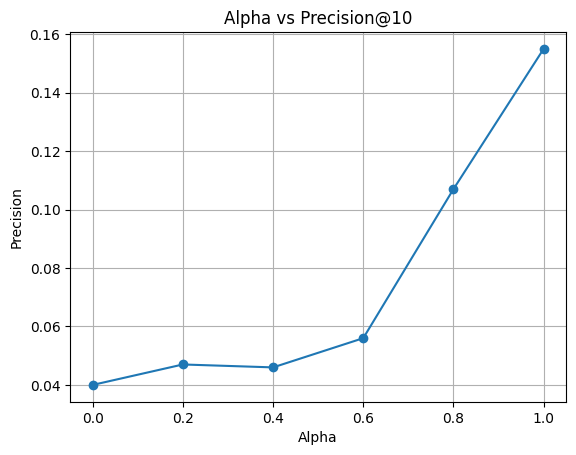

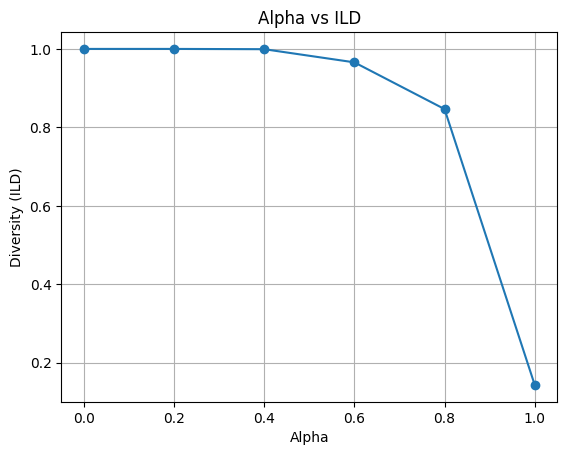

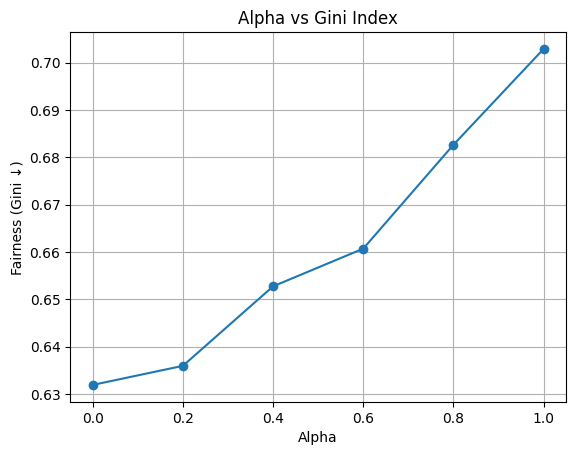

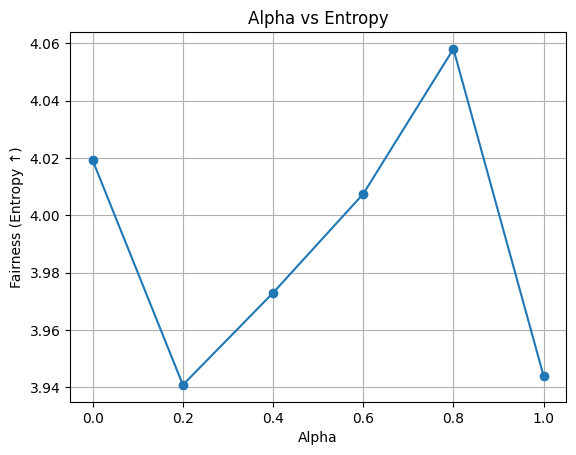

In [ ]:
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(alphas, precision_scores_train, marker='o')
plt.title("Alpha vs Precision@10")
plt.xlabel("Alpha")
plt.ylabel("Precision")
plt.grid()
plt.show()

# ILD
plt.figure()
plt.plot(alphas, ild_scores_train, marker='o')
plt.title("Alpha vs ILD")
plt.xlabel("Alpha")
plt.ylabel("Diversity (ILD)")
plt.grid()
plt.show()

# Gini
plt.figure()
plt.plot(alphas, gini_scores_train, marker='o')
plt.title("Alpha vs Gini Index")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Gini ↓)")
plt.grid()
plt.show()

# Entropy
plt.figure()
plt.plot(alphas, entropy_scores_train, marker='o')
plt.title("Alpha vs Entropy")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Entropy ↑)")
plt.grid()
plt.show()

The alpha parameter controls the trade-off between accuracy and fairness/diversity, with lower values improving fairness and diversity at the cost of accuracy.

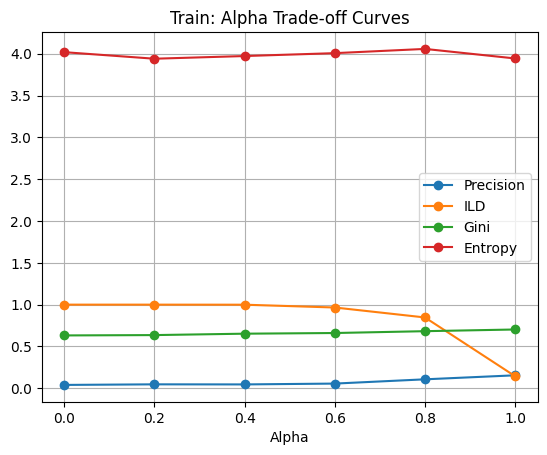

In [ ]:
plt.figure()

plt.plot(alphas, precision_scores_train, marker='o', label="Precision")
plt.plot(alphas, ild_scores_train, marker='o', label="ILD")
plt.plot(alphas, gini_scores_train, marker='o', label="Gini")
plt.plot(alphas, entropy_scores_train, marker='o', label="Entropy")

plt.title("Train: Alpha Trade-off Curves")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()

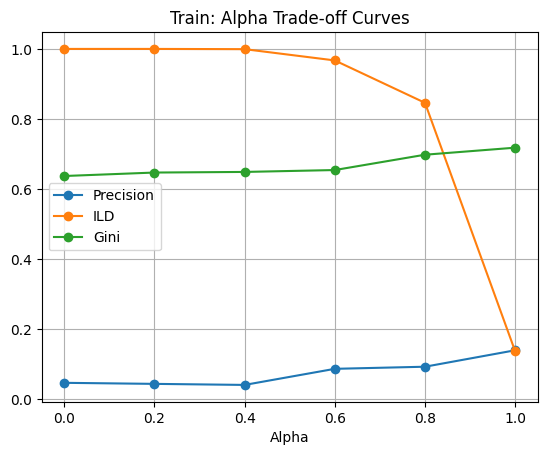

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(alphas, precision_scores_train, marker='o', label="Precision")
plt.plot(alphas, ild_scores_train, marker='o', label="ILD")
plt.plot(alphas, gini_scores_train, marker='o', label="Gini")

plt.title("Train: Alpha Trade-off Curves")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()

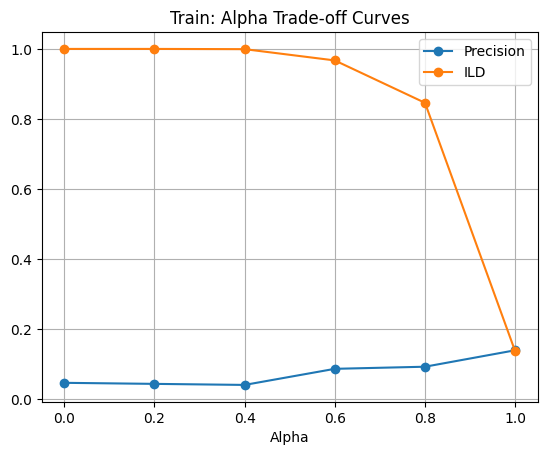

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(alphas, precision_scores_train, marker='o', label="Precision")
plt.plot(alphas, ild_scores_train, marker='o', label="ILD")

plt.title("Train: Alpha Trade-off Curves")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()

In [ ]:
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

s_recall_scores_train = []
chc_scores_train = []
hch_scores_train = []

for alpha in alphas:

    print(f"Running alpha = {alpha}")

    # S-Recall
    s = evaluate_s_recall(
        model, interactions, dataset,
        inv_item_map, news_cluster_map,
        user_clicks, method="adf", alpha=alpha
    )

    chc = evaluate_chc(
        model, interactions, dataset,
        inv_item_map, news_cluster_map,
        user_hist_dist,
        news_category_map,
        method="adf", alpha=alpha
    )

    hch = evaluate_hch(
        model, interactions, dataset,
        inv_item_map, news_cluster_map,
        user_hier_dist,
        news_hierarchy_map,
        method="adf", alpha=alpha
    )

    s_recall_scores_train.append(s)
    chc_scores_train.append(chc)
    hch_scores_train.append(hch)

print("Printing lists for easy access later...")
print(f"{s_recall_scores_train=}")
print(f"{chc_scores_train=}")
print(f"{hch_scores_train=}")

Running alpha = 0.0
Running alpha = 0.2
Running alpha = 0.4
Running alpha = 0.6
Running alpha = 0.8
Running alpha = 1.0
Printing lists for easy access later...
s_recall_scores_train=[0.4, 0.41, 0.43, 0.58, 0.66, 0.74]
chc_scores_train=[np.float64(0.39117782217782215), np.float64(0.3738701103944511), np.float64(0.364752225586591), np.float64(0.4110154575370564), np.float64(0.4247202062643239), np.float64(0.37510010603431654)]
hch_scores_train=[np.float64(0.24219161665629052), np.float64(0.25722268603504295), np.float64(0.2688599952779132), np.float64(0.2574948939476675), np.float64(0.282306249248496), np.float64(0.3068138165364322)]


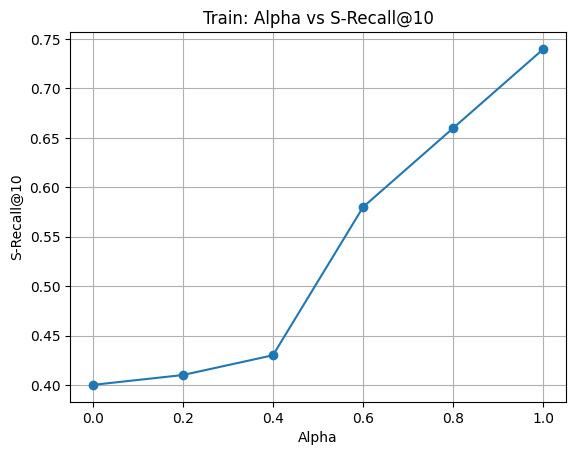

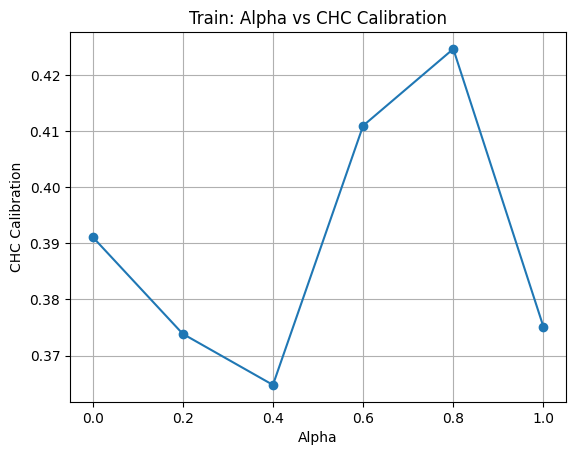

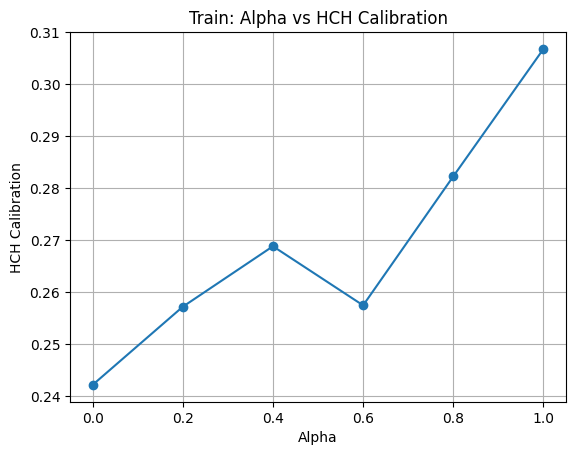

In [ ]:
import matplotlib.pyplot as plt

# S-Recall
plt.figure()
plt.plot(alphas, s_recall_scores_train, marker='o')
plt.title("Train: Alpha vs S-Recall@10")
plt.xlabel("Alpha")
plt.ylabel("S-Recall@10")
plt.grid()
plt.show()

# CHC Calibration
plt.figure()
plt.plot(alphas, chc_scores_train, marker='o')
plt.title("Train: Alpha vs CHC Calibration")
plt.xlabel("Alpha")
plt.ylabel("CHC Calibration")
plt.grid()
plt.show()

# HCH Calibration
plt.figure()
plt.plot(alphas, hch_scores_train, marker='o')
plt.title("Train: Alpha vs HCH Calibration")
plt.xlabel("Alpha")
plt.ylabel("HCH Calibration")
plt.grid()
plt.show()

# Unseen Data Evaluation

In [ ]:
# Load test data
dev_path = "/content/drive/MyDrive/ME_PROJECT/Implementation/data/MINDsmall_dev/behaviors.tsv"

dev_behaviors = pd.read_csv(
    dev_path,
    sep="\t",
    names=columns
)

print("Dev shape:", dev_behaviors.shape)
dev_behaviors.head()

Dev shape: (73152, 5)


,impression_id,user_id,time,history,impressions
0,1,U80234,11/15/2019 12:37:50 PM,N55189 N46039 N51741 N53234 N11276 N264 N40716...,N28682-0 N48740-0 N31958-1 N34130-0 N6916-0 N5...
1,2,U60458,11/15/2019 7:11:50 AM,N58715 N32109 N51180 N33438 N54827 N28488 N611...,N20036-0 N23513-1 N32536-0 N46976-0 N35216-0 N...
2,3,U44190,11/15/2019 9:55:12 AM,N56253 N1150 N55189 N16233 N61704 N51706 N5303...,N36779-0 N62365-0 N58098-0 N5472-0 N13408-0 N5...
3,4,U87380,11/15/2019 3:12:46 PM,N63554 N49153 N28678 N23232 N43369 N58518 N444...,N6950-0 N60215-0 N6074-0 N11930-0 N6916-0 N248...
4,5,U9444,11/15/2019 8:25:46 AM,N51692 N18285 N26015 N22679 N55556,N5940-1 N23513-0 N49285-0 N23355-0 N19990-0 N3...


In [ ]:
dev_ground_truth = {}

for _, row in dev_behaviors.iterrows():

    user = row["user_id"]
    impressions = row["impressions"].split()

    clicked_items = []

    for imp in impressions:
        news_id, label = imp.split("-")

        if label == "1":
            clicked_items.append(news_id)

    if len(clicked_items) > 0:
        dev_ground_truth[user] = clicked_items

In [ ]:
print("Users with ground truth:", len(dev_ground_truth))

Users with ground truth: 50000


In [ ]:
# Users present in BOTH train and dev
user_id_map, _, _, _ = dataset.mapping()

train_users = set(user_id_map.keys())
dev_users = set(dev_ground_truth.keys())

common_users = list(train_users & dev_users)

print("Common users:", len(common_users))

Common users: 5943


## ADF for Unseen Dev data evaluation

In [ ]:
dev_data = []

for _, row in dev_behaviors.iterrows():

    user = row["user_id"]
    impressions = row["impressions"].split()

    candidates = []
    clicked = []

    for imp in impressions:
        news_id, label = imp.split("-")
        candidates.append(news_id)

        if label == "1":
            clicked.append(news_id)

    if len(clicked) > 0:
        dev_data.append((user, candidates, clicked))

In [ ]:
dev_candidates_only = [item[1] for item in dev_data]

print(f"Number of entries in dev_candidates_only: {len(dev_candidates_only)}")
# Print first 5 candidates of the first user
print(f"First entry: {dev_candidates_only[0][:5]}")

Number of entries in dev_candidates_only: 73152
First entry: ['N28682', 'N48740', 'N31958', 'N34130', 'N6916']


### ADF Precision Metric on unseen dev data

In [ ]:
def precision_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    hits = 0
    for item in recommended_k:
        if item in ground_truth:
            hits += 1

    return hits / k

In [ ]:
all_candidate_set = set()

for candidate in dev_candidates_only:
    all_candidate_set.update(candidate)

print(f"Number of unique candidates: {len(all_candidate_set)}")

Number of unique candidates: 5369


In [ ]:
def get_cf_recommendations_for_candidates(user_index, model, candidates,
                                          item_id_map, inv_item_map, top_k=10):

    item_indices = [item_id_map[nid] for nid in candidates if nid in item_id_map]

    if not item_indices:
        return []

    scores = model.predict(user_index, item_indices)

    ranked_idx = np.argsort(-scores)

    # Ensure ranked_idx does not exceed the bounds of item_indices
    num_items_to_recommend = min(top_k, len(ranked_idx))
    ranked_items_indices = ranked_idx[:num_items_to_recommend]

    return [inv_item_map[item_indices[i]] for i in ranked_items_indices]

In [ ]:
def ad_rerank_greedy_candidates(user_index, model, candidates, item_id_map,
                                inv_item_map, news_cluster_map,
                                alpha=0.7, top_k=10):

    item_indices = [item_id_map[nid] for nid in candidates if nid in item_id_map]

    if not item_indices:
        return []

    scores_array = model.predict(user_index, item_indices)

    # map item_index → score
    scores = {item_indices[i]: scores_array[i] for i in range(len(item_indices))}

    ranked_items = list(item_indices)

    selected_items_indices = [] # Store item indices directly
    cluster_counts = {}

    for _ in range(min(top_k, len(ranked_items))):

        best_item_idx = None
        best_score = -np.inf
        best_cluster = None

        for item_idx in ranked_items:

            news_id = inv_item_map[item_idx]
            cluster = news_cluster_map.get(news_id, -1)

            penalty = cluster_counts.get(cluster, 0)

            final_score = alpha * scores[item_idx] - (1 - alpha) * penalty

            if final_score > best_score:
                best_score = final_score
                best_item_idx = item_idx
                best_cluster = cluster

        # add best item index
        selected_items_indices.append(best_item_idx)

        # update cluster counts
        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        # remove selected item index
        ranked_items.remove(best_item_idx)

    return [inv_item_map[item_idx] for item_idx in selected_items_indices]

In [ ]:
def af_rerank_greedy_candidates(user_index, model, candidates, item_id_map,
                                inv_item_map, news_cluster_map, top_k=10):

    item_indices = [item_id_map[nid] for nid in candidates if nid in item_id_map]

    if not item_indices:
        return []

    scores_array = model.predict(user_index, item_indices)

    # map item_index → score
    scores = {item_indices[i]: scores_array[i] for i in range(len(item_indices))}

    ranked_items = list(item_indices)

    selected_items_indices = [] # Store item indices directly
    cluster_counts = {}

    # compute number of clusters (excluding noise)
    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)

    target_per_cluster = top_k / num_clusters if num_clusters > 0 else top_k

    for _ in range(min(top_k, len(ranked_items))):

        best_item_idx = None
        best_score = -np.inf
        best_cluster = None

        for item_idx in ranked_items:

            news_id = inv_item_map[item_idx]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            # fairness penalty
            if count > target_per_cluster:
                penalty = 5  # strong penalty
            else:
                penalty = 0

            final_score = scores[item_idx] - penalty

            if final_score > best_score:
                best_score = final_score
                best_item_idx = item_idx
                best_cluster = cluster

        selected_items_indices.append(best_item_idx)

        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1

        ranked_items.remove(best_item_idx)

    return [inv_item_map[item_idx] for item_idx in selected_items_indices]

In [ ]:
def adf_rerank_greedy_candidates(user_index, model, candidates,
                                 item_id_map, inv_item_map,
                                 news_cluster_map, alpha=0.7, top_k=10):

    item_indices = [item_id_map[nid] for nid in candidates if nid in item_id_map]

    if not item_indices:
        return []

    scores_array = model.predict(user_index, item_indices)

    # map item_index → score
    scores = {item_indices[i]: scores_array[i] for i in range(len(item_indices))}

    ranked_items = list(item_indices)

    selected_items = []
    cluster_counts = {}

    valid_clusters = [c for c in set(news_cluster_map.values()) if c != -1]
    num_clusters = len(valid_clusters)
    target_per_cluster = top_k / num_clusters if num_clusters > 0 else top_k

    for _ in range(min(top_k, len(ranked_items))):

        best_item = None
        best_score = -np.inf
        best_cluster = None

        for item in ranked_items:

            news_id = inv_item_map[item]
            cluster = news_cluster_map.get(news_id, -1)

            count = cluster_counts.get(cluster, 0)

            diversity_penalty = count
            fairness_penalty = max(0, count - target_per_cluster)

            final_score = (
                alpha * scores[item]
                - (1 - alpha) * diversity_penalty
                - (1 - alpha) * fairness_penalty
            )

            if final_score > best_score:
                best_score = final_score
                best_item = item
                best_cluster = cluster

        selected_items.append(best_item)
        cluster_counts[best_cluster] = cluster_counts.get(best_cluster, 0) + 1
        ranked_items.remove(best_item)

    return [inv_item_map[item] for item in selected_items]

In [ ]:
def evaluate_precision_dev(model, dataset, dev_data,
                           inv_item_map, news_cluster_map,
                           method="cf", alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    # print("Users:", len(user_id_map))
    # print("Items:", len(item_id_map))

    # # check sample
    # print(list(item_id_map.items())[:5])

    precisions = []

    for user, candidates, clicked in dev_data:
        # print(f"evaluate_precision_dev {user=} "
        #       f"{len(clicked)=} {len(candidates)=}")

        if user not in user_id_map:
            continue

        user_index = user_id_map[user]

        if method == "cf":
            recs = get_cf_recommendations_for_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map
            )

        elif method == "ad":
            recs = ad_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        elif method == "af":
            recs = af_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map
            )

        elif method == "adf":
            recs = adf_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        else:
            continue

        prec = precision_at_k(recs, set(clicked), k=10)
        precisions.append(prec)

    return np.mean(precisions) if precisions else 0

In [ ]:
cf_score = evaluate_precision_dev(model, dataset, dev_data, inv_item_map,
                                 news_cluster_map, method="cf")

ad_score = evaluate_precision_dev(model, dataset, dev_data, inv_item_map,
                                 news_cluster_map, method="ad")

af_score = evaluate_precision_dev(model, dataset, dev_data, inv_item_map,
                                 news_cluster_map, method="af")

adf_score = evaluate_precision_dev(model, dataset, dev_data, inv_item_map,
                                  news_cluster_map, method="adf")

print("DEV Precision@10:")
print("CF :", cf_score)
print("AD :", ad_score)
print("AF :", af_score)
print("ADF:", adf_score)

DEV Precision@10:
CF : 0.045060832682219
AD : 0.04424600959928563
AF : 0.04442460095992856
ADF: 0.04422368567920527


### IDF metric on unseen dev data
Unlike Precision, ILD does NOT use ground truth

In [ ]:
from itertools import combinations

def ild_score(recommended_items, news_cluster_map):

    if len(recommended_items) < 2:
        return 0

    pairs = list(combinations(recommended_items, 2))

    dissimilarities = []

    for item1, item2 in pairs:
        c1 = news_cluster_map.get(item1, -1)
        c2 = news_cluster_map.get(item2, -1)

        if c1 == c2:
            dissimilarities.append(0)
        else:
            dissimilarities.append(1)

    return sum(dissimilarities) / len(dissimilarities)

In [ ]:
def evaluate_ild_dev(model, dataset, dev_data, inv_item_map,
                     news_cluster_map, method="cf", alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    ild_scores = []

    for user, candidates, clicked in dev_data:

        if user not in user_id_map:
            continue

        user_index = user_id_map[user]

        # get recommendations (candidate-based)
        if method == "cf":
            recs = get_cf_recommendations_for_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map
            )

        elif method == "ad":
            recs = ad_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        elif method == "af":
            recs = af_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map
            )

        elif method == "adf":
            recs = adf_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        else:
            continue

        if len(recs) == 0:
            continue

        ild = ild_score(recs, news_cluster_map)
        ild_scores.append(ild)

    return np.mean(ild_scores) if ild_scores else 0

In [ ]:
cf_ild = evaluate_ild_dev(model, dataset, dev_data, inv_item_map,
                          news_cluster_map, method="cf")

ad_ild = evaluate_ild_dev(model, dataset, dev_data, inv_item_map,
                          news_cluster_map, method="ad")

af_ild = evaluate_ild_dev(model, dataset, dev_data, inv_item_map,
                          news_cluster_map, method="af")

adf_ild = evaluate_ild_dev(model, dataset, dev_data, inv_item_map,
                           news_cluster_map, method="adf")

print("DEV ILD Results:")
print("CF :", cf_ild)
print("AD :", ad_ild)
print("AF :", af_ild)
print("ADF:", adf_ild)

DEV ILD Results:
CF : 0.050102369310758205
AD : 0.16753343839657336
AF : 0.15067752320146552
ADF: 0.1746912083619563


### Coverage, Entropy, Gini on Unseen Dev data
These are system-level metrics, not per-user so we aggregate across ALL impressions, not average per user.

In [ ]:
import numpy as np

def gini_index(exposures):
    exposures = np.array(exposures)
    exposures = exposures + 1e-9  # avoid division by zero

    exposures_sorted = np.sort(exposures)
    n = len(exposures)

    index = np.arange(1, n + 1)

    return (np.sum((2 * index - n - 1) * exposures_sorted)) / (n * np.sum(exposures_sorted))


def entropy(exposures):
    exposures = np.array(exposures)
    probs = exposures / np.sum(exposures)

    return -np.sum(probs * np.log(probs + 1e-9))

In [ ]:
def evaluate_coverage_dev(model, dataset, dev_data, inv_item_map,
                          news_cluster_map, method="cf", alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    recommended_items = set()

    for user, candidates, clicked in dev_data:

        if user not in user_id_map:
            continue

        user_index = user_id_map[user]

        if method == "cf":
            recs = get_cf_recommendations_for_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map
            )

        elif method == "ad":
            recs = ad_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        elif method == "af":
            recs = af_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map
            )

        elif method == "adf":
            recs = adf_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        else:
            continue

        if len(recs) == 0:
            continue

        recommended_items.update(recs[:10])  # consistent K

    return len(recommended_items)

In [ ]:
from collections import defaultdict

def get_exposure_distribution_dev(model, dataset,
                                  dev_data, inv_item_map,
                                  news_cluster_map, method="cf",
                                  alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    exposure_counts = defaultdict(int)

    for user, candidates, clicked in dev_data:

        if user not in user_id_map:
            continue

        user_index = user_id_map[user]

        if method == "cf":
            recs = get_cf_recommendations_for_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map
            )

        elif method == "ad":
            recs = ad_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        elif method == "af":
            recs = af_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map
            )

        elif method == "adf":
            recs = adf_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        else:
            continue

        if len(recs) == 0:
            continue

        for item in recs[:10]:  # consistent K
            exposure_counts[item] += 1

    return list(exposure_counts.values())

In [ ]:
# Coverage
cf_cov = evaluate_coverage_dev(model, dataset, dev_data, inv_item_map,
                              news_cluster_map, method="cf")

ad_cov = evaluate_coverage_dev(model, dataset, dev_data, inv_item_map,
                              news_cluster_map, method="ad")

af_cov = evaluate_coverage_dev(model, dataset, dev_data, inv_item_map,
                              news_cluster_map, method="af")

adf_cov = evaluate_coverage_dev(model, dataset, dev_data, inv_item_map,
                               news_cluster_map, method="adf")

print("Coverage:")
print("CF :", cf_cov)
print("AD :", ad_cov)
print("AF :", af_cov)
print("ADF:", adf_cov)


# Exposure distributions
cf_exp = get_exposure_distribution_dev(model, dataset, dev_data,
                                       inv_item_map,
                                       news_cluster_map,
                                       method="cf")

ad_exp = get_exposure_distribution_dev(model, dataset, dev_data,
                                       inv_item_map,
                                       news_cluster_map,
                                       method="ad")

af_exp = get_exposure_distribution_dev(model, dataset, dev_data,
                                       inv_item_map,
                                       news_cluster_map,
                                       method="af")

adf_exp = get_exposure_distribution_dev(model, dataset, dev_data,
                                        inv_item_map,
                                        news_cluster_map,
                                        method="adf")


print("\nGini:")
print("CF :", gini_index(cf_exp))
print("AD :", gini_index(ad_exp))
print("AF :", gini_index(af_exp))
print("ADF:", gini_index(adf_exp))

print("\nEntropy:")
print("CF :", entropy(cf_exp))
print("AD :", entropy(ad_exp))
print("AF :", entropy(af_exp))
print("ADF:", entropy(adf_exp))

Coverage:
CF : 681
AD : 670
AF : 672
ADF: 666

Gini:
CF : 0.8738029693133778
AD : 0.8722520308143767
AF : 0.8717241735646303
ADF: 0.8725351272393865

Entropy:
CF : 4.552986158558353
AD : 4.565895170102322
AF : 4.572809389816592
ADF: 4.559242325619278


**Coverage**:
- If CF keeps recommending same popular items -> low coverage
- If recommendations are spread out -> high coverage

**Gini Index**: Measures inequality of item exposure
- High Gini -> unfair (few items dominate)
- Low Gini -> fair (balanced exposure)

**Entropy**: Measures distribution spread
- High entropy -> more balanced exposure
- Low entropy -> skewed distribution

Under full catalog ranking, ADF significantly improves diversity and fairness.
However, under realistic candidate-based evaluation (MIND dev), the impact is limited because the candidate generation stage already constrains item exposure.

### S-Recall@10 on unseen dev data

In [ ]:
def s_recall_at_k(recommended_items, ground_truth, k=10):

    recommended_k = recommended_items[:k]

    for item in recommended_k:
        if item in ground_truth:
            return 1  # success

    return 0  # failure

In [ ]:
def evaluate_s_recall_dev(model, dataset, dev_data,
                          inv_item_map, news_cluster_map,
                          method="cf", alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    successes = []

    for user, candidates, clicked in dev_data:

        if user not in user_id_map:
            continue

        user_index = user_id_map[user]

        if method == "cf":
            recs = get_cf_recommendations_for_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map
            )

        elif method == "ad":
            recs = ad_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        elif method == "af":
            recs = af_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map
            )

        elif method == "adf":
            recs = adf_rerank_greedy_candidates(
                user_index, model, candidates,
                item_id_map, inv_item_map,
                news_cluster_map, alpha
            )

        else:
            continue

        if len(recs) == 0:
            continue

        srec = s_recall_at_k(recs, set(clicked), k=10)
        successes.append(srec)

    return np.mean(successes) if successes else 0

In [ ]:
cf_srec = evaluate_s_recall_dev(model, dataset, dev_data,
                               inv_item_map, news_cluster_map, method="cf")

ad_srec = evaluate_s_recall_dev(model, dataset, dev_data,
                               inv_item_map, news_cluster_map, method="ad")

af_srec = evaluate_s_recall_dev(model, dataset, dev_data,
                               inv_item_map, news_cluster_map, method="af")

adf_srec = evaluate_s_recall_dev(model, dataset, dev_data,
                                inv_item_map, news_cluster_map, method="adf")

print("DEV S-Recall@10:")
print("CF :", cf_srec)
print("AD :", ad_srec)
print("AF :", af_srec)
print("ADF:", adf_srec)

DEV S-Recall@10:
CF : 0.4370226694144745
AD : 0.4309613286458965
AF : 0.4321735967996121
ADF: 0.4312037822766396


### Calibration dev

#### CHC dev

In [ ]:
def evaluate_chc_dev(model, dataset, dev_data,
                     inv_item_map,
                     news_cluster_map,
                     user_hist_dist,
                     news_category_map,
                     method="cf",
                     alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    chc_scores = []

    for user, candidates, clicked in dev_data:

        if user not in user_id_map:
            continue

        if user not in user_hist_dist:
            continue

        user_index = user_id_map[user]

        historical_distribution = user_hist_dist[user]

        if method == "cf":

            recs = get_cf_recommendations_for_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map
            )

        elif method == "ad":

            recs = ad_rerank_greedy_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map,
                news_cluster_map,
                alpha
            )

        elif method == "af":

            recs = af_rerank_greedy_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map,
                news_cluster_map
            )

        elif method == "adf":

            recs = adf_rerank_greedy_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map,
                news_cluster_map,
                alpha
            )

        else:
            continue

        if len(recs) == 0:
            continue

        chc = chc_score(
            recs,
            historical_distribution,
            news_category_map
        )

        chc_scores.append(chc)

    return np.mean(chc_scores) if chc_scores else 0

In [ ]:
cf_chc = evaluate_chc_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="cf"
)

ad_chc = evaluate_chc_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="ad"
)

af_chc = evaluate_chc_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="af"
)

adf_chc = evaluate_chc_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hist_dist,
    news_category_map,
    method="adf"
)

print("CHC Results (DEV):")
print("CF :", cf_chc)
print("AD :", ad_chc)
print("AF :", af_chc)
print("ADF:", adf_chc)

CHC Results (DEV):
CF : 0.30700871326965046
AD : 0.30201443205833967
AF : 0.30340482499891186
ADF: 0.3014553718929004


#### HCH dev

In [ ]:
def evaluate_hch_dev(model, dataset, dev_data,
                     inv_item_map,
                     news_cluster_map,
                     user_hist_dist,
                     news_hierarchy_map,
                     method="cf",
                     alpha=0.7):

    user_id_map, _, item_id_map, _ = dataset.mapping()

    hch_scores = []

    for user, candidates, clicked in dev_data:

        if user not in user_id_map:
            continue

        if user not in user_hist_dist:
            continue

        user_index = user_id_map[user]

        historical_distribution = user_hist_dist[user]

        if method == "cf":

            recs = get_cf_recommendations_for_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map
            )

        elif method == "ad":

            recs = ad_rerank_greedy_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map,
                news_cluster_map,
                alpha
            )

        elif method == "af":

            recs = af_rerank_greedy_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map,
                news_cluster_map
            )

        elif method == "adf":

            recs = adf_rerank_greedy_candidates(
                user_index,
                model,
                candidates,
                item_id_map,
                inv_item_map,
                news_cluster_map,
                alpha
            )

        else:
            continue

        if len(recs) == 0:
            continue

        hch = hch_score(
            recs,
            historical_distribution,
            news_hierarchy_map
        )

        hch_scores.append(hch)

    return np.mean(hch_scores) if hch_scores else 0

In [ ]:
cf_hch = evaluate_hch_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="cf"
)

ad_hch = evaluate_hch_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="ad"
)

af_hch = evaluate_hch_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="af"
)

adf_hch = evaluate_hch_dev(
    model, dataset, dev_data,
    inv_item_map,
    news_cluster_map,
    user_hier_dist,
    news_hierarchy_map,
    method="adf"
)

print("HCH Results (DEV):")
print("CF :", cf_hch)
print("AD :", ad_hch)
print("AF :", af_hch)
print("ADF:", adf_hch)

HCH Results (DEV):
CF : 0.21712482353821225
AD : 0.21374453092189888
AF : 0.21465510369088092
ADF: 0.21324499865504104


### α Sweep Graphs for unseen dev data

In [ ]:
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

precision_scores = []
ild_scores = []
gini_scores = []
entropy_scores = []

for alpha in alphas:

    print(f"Running alpha = {alpha}")

    # Precision (DEV)
    p = evaluate_precision_dev(
        model, dataset, dev_data,
        inv_item_map, news_cluster_map,
        method="adf", alpha=alpha
    )

    # ILD (DEV)
    ild = evaluate_ild_dev(
        model, dataset, dev_data,
        inv_item_map, news_cluster_map,
        method="adf", alpha=alpha
    )

    # Exposure (DEV)
    exp = get_exposure_distribution_dev(
        model, dataset, dev_data,
        inv_item_map, news_cluster_map,
        method="adf", alpha=alpha
    )

    # Safety (important!)
    if len(exp) == 0:
        g = 0
        e = 0
    else:
        g = gini_index(exp)
        e = entropy(exp)

    precision_scores.append(p)
    ild_scores.append(ild)
    gini_scores.append(g)
    entropy_scores.append(e)


print("Printing lists for easy access later...")
print(f"{precision_scores=}")
print(f"{ild_scores=}")
print(f"{gini_scores=}")
print(f"{entropy_scores=}")

Running alpha = 0.0
Running alpha = 0.2
Running alpha = 0.4
Running alpha = 0.6
Running alpha = 0.8
Running alpha = 1.0
Printing lists for easy access later...
precision_scores=[np.float64(0.0430181939948655), np.float64(0.0441343899988838), np.float64(0.0441343899988838), np.float64(0.04415671391896417), np.float64(0.04424600959928563), np.float64(0.045060832682219)]
ild_scores=[np.float64(0.17702145714632073), np.float64(0.17702145714632073), np.float64(0.1769406392694064), np.float64(0.17624829945717327), np.float64(0.1698205843132501), np.float64(0.050102369310758205)]
gini_scores=[np.float64(0.8794015622955556), np.float64(0.8721859195133164), np.float64(0.872223146320128), np.float64(0.8722690088463654), np.float64(0.8721148955283987), np.float64(0.8738029693133778)]
entropy_scores=[np.float64(4.616793445324487), np.float64(4.553260098523285), np.float64(4.554137839793031), np.float64(4.556244433278961), np.float64(4.563393819879494), np.float64(4.552986158558353)]


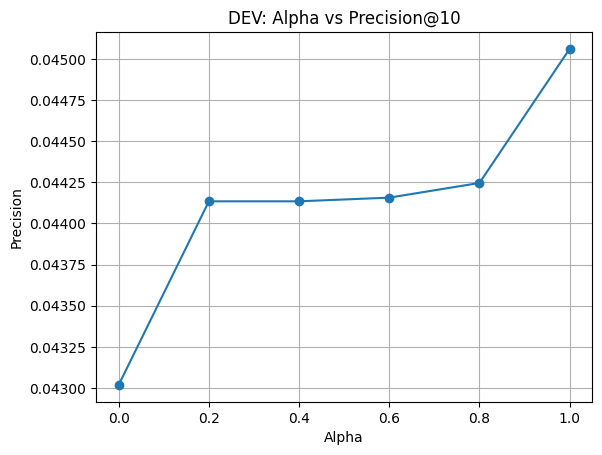

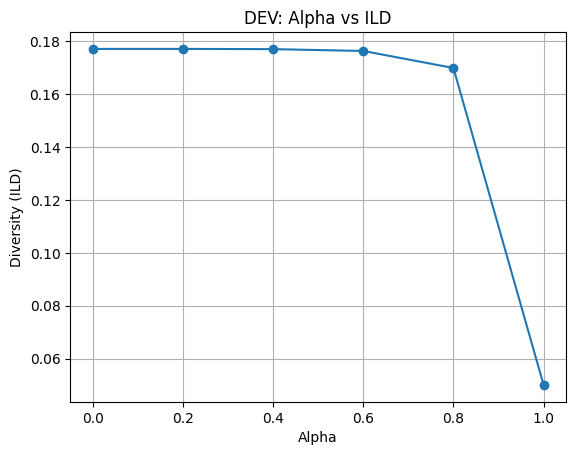

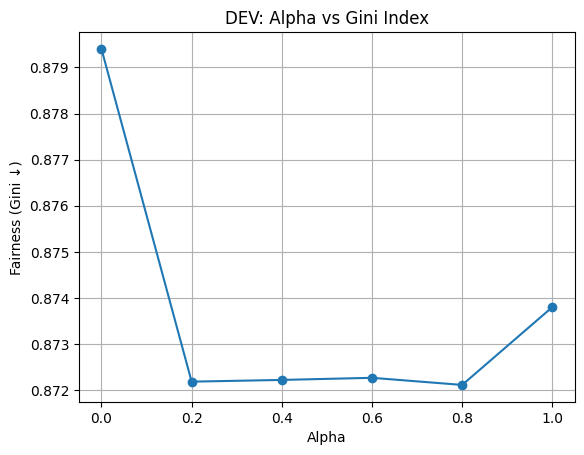

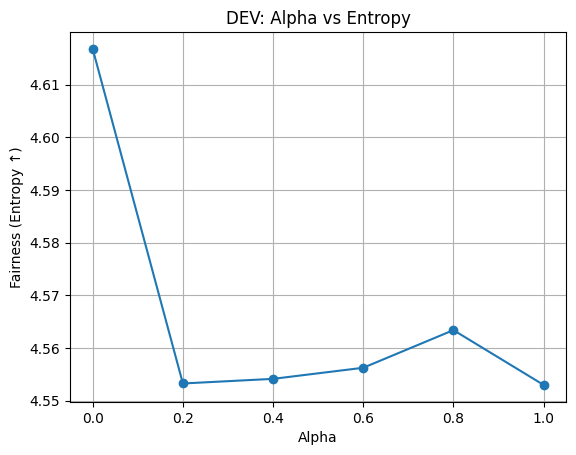

In [ ]:
import matplotlib.pyplot as plt

# Precision
plt.figure()
plt.plot(alphas, precision_scores, marker='o')
plt.title("DEV: Alpha vs Precision@10")
plt.xlabel("Alpha")
plt.ylabel("Precision")
plt.grid()
plt.show()

# ILD
plt.figure()
plt.plot(alphas, ild_scores, marker='o')
plt.title("DEV: Alpha vs ILD")
plt.xlabel("Alpha")
plt.ylabel("Diversity (ILD)")
plt.grid()
plt.show()

# Gini
plt.figure()
plt.plot(alphas, gini_scores, marker='o')
plt.title("DEV: Alpha vs Gini Index")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Gini ↓)")
plt.grid()
plt.show()

# Entropy
plt.figure()
plt.plot(alphas, entropy_scores, marker='o')
plt.title("DEV: Alpha vs Entropy")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Entropy ↑)")
plt.grid()
plt.show()

Curves have less variance at non-extremes because
* candidate set already restricted
* reranking has limited control
* fairness decisions partially made upstream

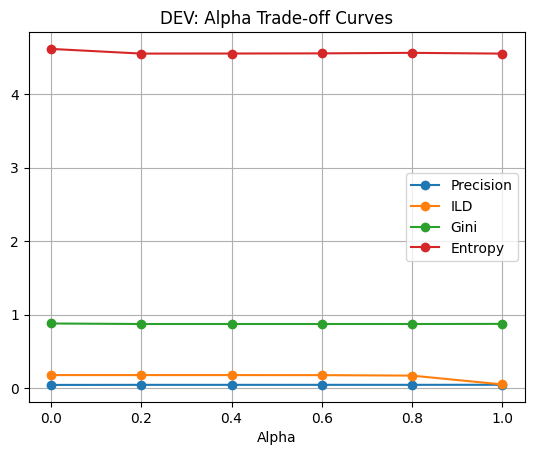

In [ ]:
plt.figure()

plt.plot(alphas, precision_scores, marker='o', label="Precision")
plt.plot(alphas, ild_scores, marker='o', label="ILD")
plt.plot(alphas, gini_scores, marker='o', label="Gini")
plt.plot(alphas, entropy_scores, marker='o', label="Entropy")

plt.title("DEV: Alpha Trade-off Curves")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()

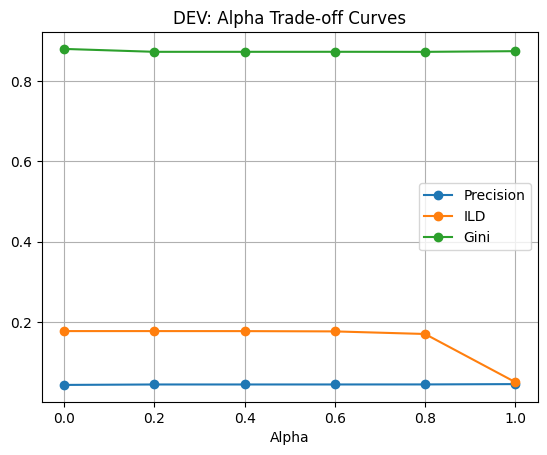

In [ ]:
plt.figure()

plt.plot(alphas, precision_scores, marker='o', label="Precision")
plt.plot(alphas, ild_scores, marker='o', label="ILD")
plt.plot(alphas, gini_scores, marker='o', label="Gini")

plt.title("DEV: Alpha Trade-off Curves")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()

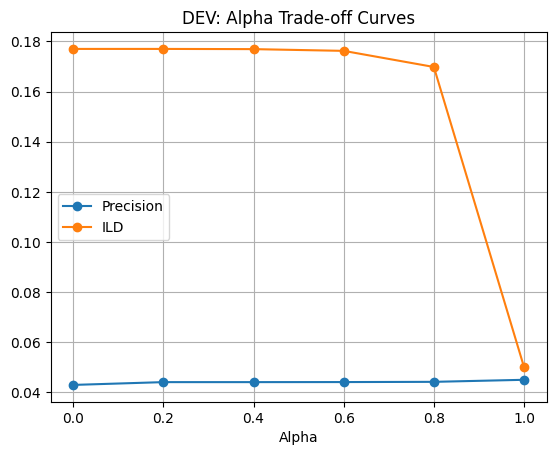

In [ ]:
plt.figure()

plt.plot(alphas, precision_scores, marker='o', label="Precision")
plt.plot(alphas, ild_scores, marker='o', label="ILD")

plt.title("DEV: Alpha Trade-off Curves")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()

In [ ]:
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

s_recall_scores = []
chc_scores = []
hch_scores = []

for alpha in alphas:

    print(f"Running alpha = {alpha}")

    # S-Recall
    s = evaluate_s_recall_dev(
        model, dataset, dev_data,
        inv_item_map, news_cluster_map,
        method="adf", alpha=alpha
    )

    chc = evaluate_chc_dev(
        model, dataset, dev_data,
        inv_item_map,
        news_cluster_map,
        user_hist_dist,
        news_category_map,
        method="adf",
        alpha=alpha
    )

    hch = evaluate_hch_dev(
        model, dataset, dev_data,
        inv_item_map,
        news_cluster_map,
        user_hier_dist,
        news_hierarchy_map,
        method="adf",
        alpha=alpha
    )

    s_recall_scores.append(s)
    chc_scores.append(chc)
    hch_scores.append(hch)

print("Printing lists for easy access later...")
print(f"{s_recall_scores=}")
print(f"{chc_scores=}")
print(f"{hch_scores=}")

Running alpha = 0.0
Running alpha = 0.2
Running alpha = 0.4
Running alpha = 0.6
Running alpha = 0.8
Running alpha = 1.0
Printing lists for easy access later...
s_recall_scores=[np.float64(0.4199296884470845), np.float64(0.43011274093829555), np.float64(0.43011274093829555), np.float64(0.4304764213844102), np.float64(0.43108255546126806), np.float64(0.4370226694144745)]
chc_scores=[np.float64(0.301420052883), np.float64(0.300953197181041), np.float64(0.3010159469085235), np.float64(0.301146017910981), np.float64(0.3018654428605411), np.float64(0.30700871326965046)]
hch_scores=[np.float64(0.21046402290388083), np.float64(0.21274488143467604), np.float64(0.2127966054919053), np.float64(0.21297357321607924), np.float64(0.2136656811796904), np.float64(0.21712482353821225)]


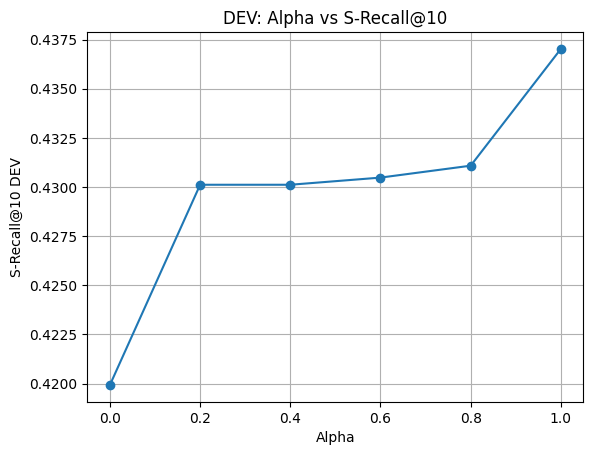

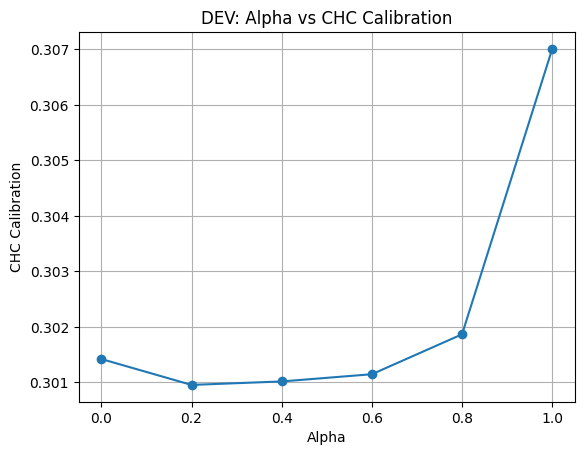

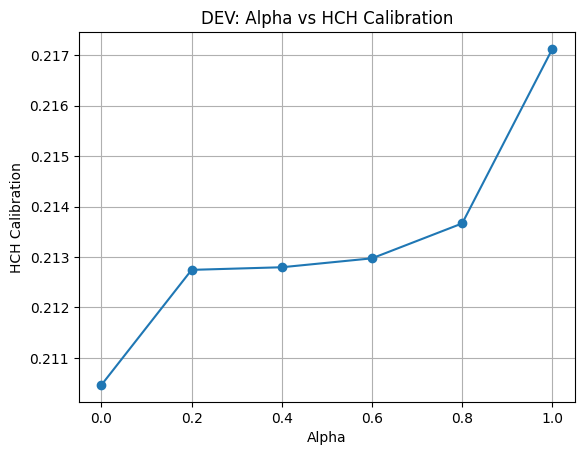

In [ ]:
import matplotlib.pyplot as plt

# S-Recall
plt.figure()
plt.plot(alphas, s_recall_scores, marker='o')
plt.title("DEV: Alpha vs S-Recall@10")
plt.xlabel("Alpha")
plt.ylabel("S-Recall@10 DEV")
plt.grid()
plt.show()

# CHC Calibration
plt.figure()
plt.plot(alphas, chc_scores, marker='o')
plt.title("DEV: Alpha vs CHC Calibration")
plt.xlabel("Alpha")
plt.ylabel("CHC Calibration")
plt.grid()
plt.show()

# HCH Calibration
plt.figure()
plt.plot(alphas, hch_scores, marker='o')
plt.title("DEV: Alpha vs HCH Calibration")
plt.xlabel("Alpha")
plt.ylabel("HCH Calibration")
plt.grid()
plt.show()

## Plotting alpha sweep curves train and text for comparison

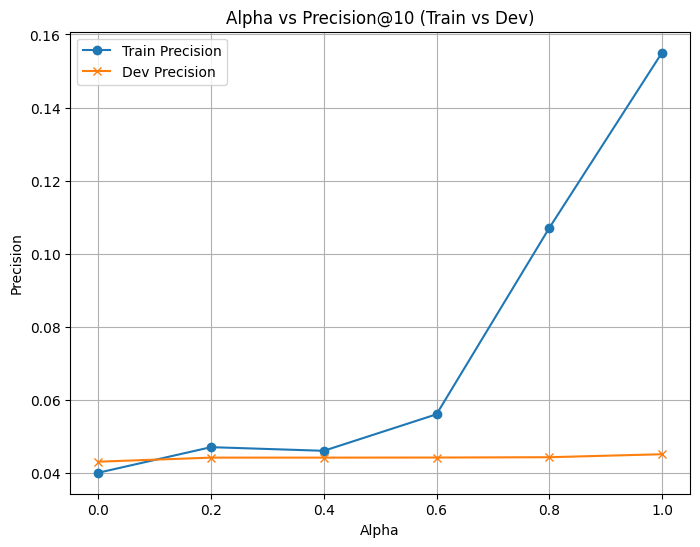

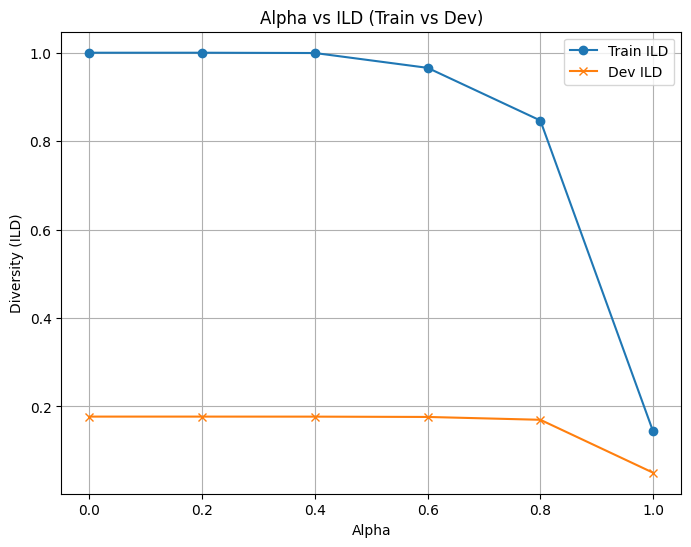

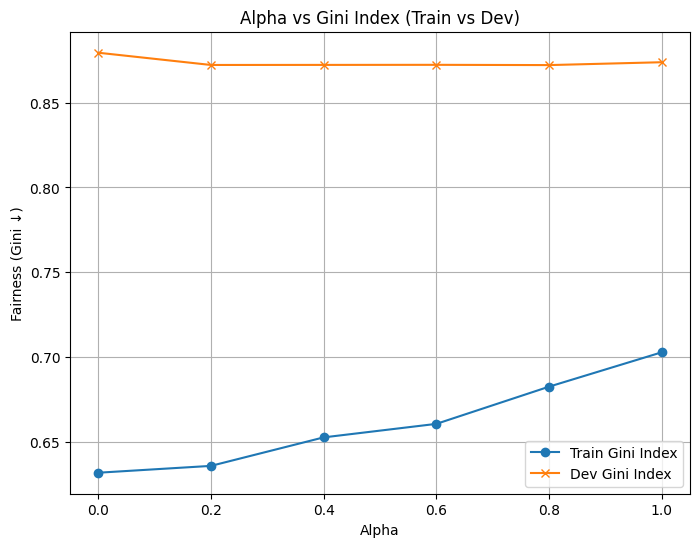

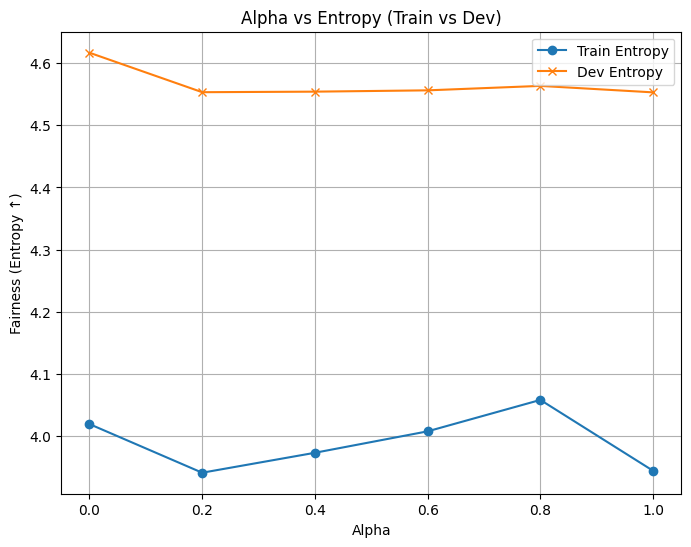

In [ ]:
import matplotlib.pyplot as plt

# Precision
plt.figure(figsize=(8, 6))
plt.plot(alphas, precision_scores_train, marker='o', label='Train Precision')
plt.plot(alphas, precision_scores, marker='x', label='Dev Precision')
plt.title("Alpha vs Precision@10 (Train vs Dev)")
plt.xlabel("Alpha")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

# ILD
plt.figure(figsize=(8, 6))
plt.plot(alphas, ild_scores_train, marker='o', label='Train ILD')
plt.plot(alphas, ild_scores, marker='x', label='Dev ILD')
plt.title("Alpha vs ILD (Train vs Dev)")
plt.xlabel("Alpha")
plt.ylabel("Diversity (ILD)")
plt.grid(True)
plt.legend()
plt.show()

# Gini
plt.figure(figsize=(8, 6))
plt.plot(alphas, gini_scores_train, marker='o', label='Train Gini Index')
plt.plot(alphas, gini_scores, marker='x', label='Dev Gini Index')
plt.title("Alpha vs Gini Index (Train vs Dev)")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Gini ↓)")
plt.grid(True)
plt.legend()
plt.show()

# Entropy
plt.figure(figsize=(8, 6))
plt.plot(alphas, entropy_scores_train, marker='o', label='Train Entropy')
plt.plot(alphas, entropy_scores, marker='x', label='Dev Entropy')
plt.title("Alpha vs Entropy (Train vs Dev)")
plt.xlabel("Alpha")
plt.ylabel("Fairness (Entropy ↑)")
plt.grid(True)
plt.legend()
plt.show()

Alpha sweep on full catalog shows clear trade-offs between accuracy and fairness.
However, under impression-based evaluation, curves become flatter due to candidate set constraints, limiting the influence of re-ranking.

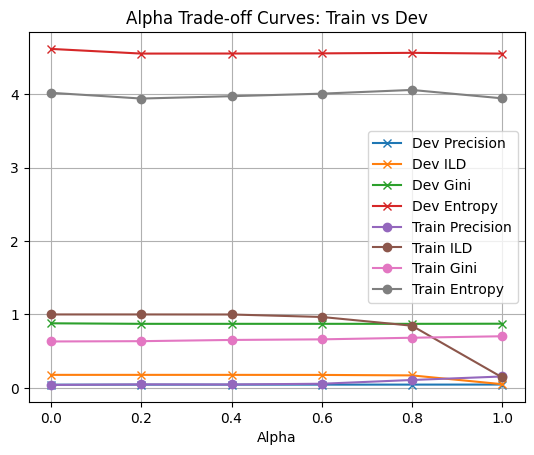

In [ ]:
plt.figure()

plt.plot(alphas, precision_scores, marker='x', label="Dev Precision")
plt.plot(alphas, ild_scores, marker='x', label="Dev ILD")
plt.plot(alphas, gini_scores, marker='x', label="Dev Gini")
plt.plot(alphas, entropy_scores, marker='x', label="Dev Entropy")

plt.plot(alphas, precision_scores_train, marker='o', label="Train Precision")
plt.plot(alphas, ild_scores_train, marker='o', label="Train ILD")
plt.plot(alphas, gini_scores_train, marker='o', label="Train Gini")
plt.plot(alphas, entropy_scores_train, marker='o', label="Train Entropy")


plt.title("Alpha Trade-off Curves: Train vs Dev")
plt.xlabel("Alpha")
plt.legend()
plt.grid()
plt.show()